In [ ]:
# ==============================================================================
# BƯỚC 0: CÀI ĐẶT MÔI TRƯỜNG
# ==============================================================================
print(" BƯỚC 0: CÀI ĐẶT MÔI TRƯỜNG ".center(80, "="))
# Cài đặt các thư viện cần thiết
!pip install -q diffusers transformers accelerate torchmetrics tqdm pandas scikit-learn gradio

import os
import gc
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Dataset, ConcatDataset, Subset
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve
import gradio as gr

# --- THIẾT LẬP CÁC THAM SỐ VÀ CẤU HÌNH CHUNG ---
torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nSử dụng thiết bị: {DEVICE}")

# Kết nối với Google Drive để lưu trữ model
from google.colab import drive
drive.mount('/content/gdrive')

SAVE_DIR = "/content/gdrive/MyDrive/Pet_OOD_Project_Contrastive_Final"
os.makedirs(SAVE_DIR, exist_ok=True)
OOD_MODEL_SAVE_PATH = os.path.join(SAVE_DIR, 'pet_ood_model_contrastive.pt')
DREAM_OOD_PATH = os.path.join(SAVE_DIR, 'dream_ood_1000_samples.npy')
print(f"Model và dữ liệu OOD sẽ được lưu tại: {SAVE_DIR}")


# ==============================================================================
# BƯỚC 1: CHUẨN BỊ DỮ LIỆU (ID, NEAR-OOD, FAR-OOD)
# ==============================================================================
print("\n" + " BƯỚC 1: CHUẨN BỊ DỮ LIỆU ".center(80, "="))

# --- 1.1. TẠO DỮ LIỆU FAR-OOD (DREAMOOD) ---
class DreamOODGenerator:
    # Chuyển sang model public, không cần đăng nhập
    def __init__(self, model_name="runwayml/stable-diffusion-v1-5"):
        from diffusers import StableDiffusionPipeline
        print(f"Đang tải model Stable Diffusion: {model_name} (Public Model)...")
        self.pipe = StableDiffusionPipeline.from_pretrained(
            model_name, torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
        )
        if torch.cuda.is_available(): self.pipe.to("cuda")
        self.ood_prompts = ["abstract geometric patterns", "random noise texture", "colorful abstract painting"]

    def generate_ood_batch(self, batch_size=8, size=(224, 224)):
        images = []
        prompts = [f"{np.random.choice(['vibrant','muted','dark'])} {np.random.choice(self.ood_prompts)}" for _ in range(batch_size)]
        with torch.no_grad():
            generated_images = self.pipe(prompts, num_inference_steps=20, height=512, width=512, guidance_scale=7.5).images
            for img in generated_images:
                images.append(np.array(img.resize(size)))
        return np.array(images)

    def create_ood_dataset(self, num_samples=1000, save_path=None):
        print(f"Đang tạo {num_samples} mẫu Far-OOD (DreamOOD)...")
        batch_size = 16
        num_batches = (num_samples + batch_size - 1) // batch_size
        all_images = np.concatenate([
            self.generate_ood_batch(min(batch_size, num_samples - i * batch_size))
            for i in tqdm(range(num_batches), desc="Generating DreamOOD")
        ])
        if save_path: np.save(save_path, all_images); print(f"Đã lưu DreamOOD dataset tại: {save_path}")
        return all_images

class DreamOODDataset(Dataset):
    def __init__(self, images, transform=None): self.images, self.transform = images, transform
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        image = Image.fromarray(self.images[idx].astype(np.uint8));
        if self.transform: image = self.transform(image)
        return image, -1

# Chỉ tạo ảnh nếu file chưa tồn tại
if not os.path.exists(DREAM_OOD_PATH):
    dream_generator = DreamOODGenerator()
    dream_ood_images = dream_generator.create_ood_dataset(num_samples=1000, save_path=DREAM_OOD_PATH)
    del dream_generator, dream_ood_images; gc.collect(); torch.cuda.empty_cache()
else:
    print("Tải DreamOOD dataset đã có...")

# --- 1.2. ĐỊNH NGHĨA CÁC PHÉP BIẾN ĐỔI ---
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224), transforms.RandomHorizontalFlip(),
        transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(224),
        transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# --- 1.3. TẢI CÁC BỘ DỮ LIỆU ---
id_dataset_full = torchvision.datasets.OxfordIIITPet(root='.', split='trainval', download=True, transform=data_transforms['train'])
train_size = int(0.9 * len(id_dataset_full)); val_size = len(id_dataset_full) - train_size
id_train_dataset, id_val_dataset = random_split(id_dataset_full, [train_size, val_size])
id_val_dataset.dataset.transform = data_transforms['val']

# [SỬA LỖI QUAN TRỌNG] Truy cập trực tiếp vào .classes từ đối tượng dataset gốc
class_names = id_dataset_full.classes
num_classes = len(class_names)
print(f"\n- Dữ liệu ID: {len(id_train_dataset)} ảnh train, {len(id_val_dataset)} ảnh val từ {num_classes} giống chó/mèo.")

near_ood_dataset_full = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=data_transforms['train'])
non_pet_indices = [i for i, label in enumerate(near_ood_dataset_full.labels) if near_ood_dataset_full.classes[label] not in ['cat', 'dog']]
near_ood_dataset = Subset(near_ood_dataset_full, non_pet_indices)
print(f"- Dữ liệu Near-OOD: {len(near_ood_dataset)} ảnh từ STL-10.")

far_ood_images = np.load(DREAM_OOD_PATH)
far_ood_dataset = DreamOODDataset(far_ood_images, transform=data_transforms['train'])
print(f"- Dữ liệu Far-OOD: {len(far_ood_dataset)} ảnh từ DreamOOD.")

ood_train_dataset = ConcatDataset([near_ood_dataset, far_ood_dataset])

# --- 1.4. TẠO DATALOADERS ---
batch_size = 32
id_train_loader = DataLoader(id_train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
id_val_loader = DataLoader(id_val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
ood_train_loader = DataLoader(ood_train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
print("\nChuẩn bị dữ liệu hoàn tất!")

# ==============================================================================
# BƯỚC 2: ĐỊNH NGHĨA MODEL VÀ LOSS FUNCTION
# ==============================================================================
print("\n" + " BƯỚC 2: ĐỊNH NGHĨA MODEL VÀ LOSS FUNCTION ".center(80, "="))
class ProjectionHead(nn.Module):
    def __init__(self, in_features, projection_dim=128): super().__init__(); self.projection = nn.Sequential(nn.Linear(in_features, in_features, bias=False), nn.ReLU(), nn.Linear(in_features, projection_dim, bias=False))
    def forward(self, x): return F.normalize(self.projection(x), p=2, dim=1)

class OODResNet18(nn.Module):
    def __init__(self, num_classes, projection_dim=128):
        super().__init__(); self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT); self.backbone_dim = self.backbone.fc.in_features; self.backbone.fc = nn.Identity(); self.projection_head = ProjectionHead(self.backbone_dim, projection_dim); self.classifier = nn.Linear(self.backbone_dim, num_classes)
    def forward(self, x, return_features=False):
        backbone_features = self.backbone(x); logits = self.classifier(backbone_features)
        if return_features: projected_features = self.projection_head(backbone_features); return logits, backbone_features, projected_features
        return logits

class ContrastiveSeparationLoss(nn.Module):
    def __init__(self, margin=2.0): super().__init__(); self.margin = margin
    def forward(self, id_features, ood_features):
        loss_id = torch.mean(torch.norm(id_features, p=2, dim=1)); loss_ood = F.relu(self.margin - torch.norm(ood_features, p=2, dim=1)).mean()
        return loss_id + loss_ood

model_ood = OODResNet18(num_classes=num_classes).to(DEVICE)
print("Định nghĩa model và loss thành công.")


# ==============================================================================
# BƯỚC 3: QUY TRÌNH HUẤN LUYỆN
# ==============================================================================
if os.path.exists(OOD_MODEL_SAVE_PATH):
    print("\n" + " ĐÃ TÌM THẤY MODEL ĐÃ HUẤN LUYỆN, BỎ QUA TRAINING ".center(80, "="))
    model_ood.load_state_dict(torch.load(OOD_MODEL_SAVE_PATH, map_location=DEVICE))
else:
    print("\n" + " BƯỚC 3: BẮT ĐẦU HUẤN LUYỆN MODEL OOD ".center(80, "="))
    epochs = 25; lr = 1e-4; contrastive_weight = 0.5
    optimizer = optim.AdamW(model_ood.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    cls_criterion = nn.CrossEntropyLoss(); contrastive_criterion = ContrastiveSeparationLoss(margin=2.0)
    best_val_acc = 0.0

    for epoch in range(epochs):
        model_ood.train(); ood_iter = iter(ood_train_loader)
        progress_bar = tqdm(id_train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for id_inputs, id_targets in progress_bar:
            id_inputs, id_targets = id_inputs.to(DEVICE), id_targets.to(DEVICE)
            try: ood_inputs, _ = next(ood_iter)
            except StopIteration: ood_iter = iter(ood_train_loader); ood_inputs, _ = next(ood_iter)
            ood_inputs = ood_inputs.to(DEVICE); optimizer.zero_grad()
            all_inputs = torch.cat([id_inputs, ood_inputs])
            logits, _, projected_features = model_ood(all_inputs, return_features=True)
            id_logits = logits[:len(id_inputs)]; id_projected_features = projected_features[:len(id_inputs)]; ood_projected_features = projected_features[len(id_inputs):]
            loss_cls = cls_criterion(id_logits, id_targets); loss_contrastive = contrastive_criterion(id_projected_features, ood_projected_features)
            total_loss = loss_cls + contrastive_weight * loss_contrastive
            total_loss.backward(); optimizer.step()
            progress_bar.set_postfix(loss=f"{total_loss.item():.4f}")

        model_ood.eval(); val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, targets in id_val_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE); outputs = model_ood(inputs); _, predicted = torch.max(outputs.data, 1); val_total += targets.size(0); val_correct += (predicted == targets).sum().item()
        val_accuracy = 100 * val_correct / val_total
        print(f"Epoch {epoch+1:02d}: Validation Accuracy: {val_accuracy:.2f}%")
        scheduler.step()
        if val_accuracy > best_val_acc:
            print(f"  -> Val accuracy improved ({best_val_acc:.2f}% -> {val_accuracy:.2f}%). Saving model..."); torch.save(model_ood.state_dict(), OOD_MODEL_SAVE_PATH); best_val_acc = val_accuracy
    print("\n--- HUẤN LUYỆN HOÀN TẤT ---")
    model_ood.load_state_dict(torch.load(OOD_MODEL_SAVE_PATH))

# ==============================================================================
# BƯỚC 4: ĐÁNH GIÁ CHI TIẾT HIỆU SUẤT MODEL
# ==============================================================================
print("\n" + " BƯỚC 4: ĐÁNH GIÁ CHI TIẾT HIỆU SUẤT ".center(80, "="))
# --- 4.1. Chuẩn bị các bộ dữ liệu Test ---
print("Chuẩn bị các bộ dữ liệu để đánh giá...")
id_test_dataset = torchvision.datasets.OxfordIIITPet(root='.', split='test', download=True, transform=data_transforms['val'])
id_test_loader = DataLoader(id_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
near_ood_test_full = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=data_transforms['val'])
non_pet_indices_test = [i for i, label in enumerate(near_ood_test_full.labels) if near_ood_test_full.classes[label] not in ['cat', 'dog']]
near_ood_test_dataset = Subset(near_ood_test_full, non_pet_indices_test)
near_ood_test_loader = DataLoader(near_ood_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
far_ood_test_dataset = torchvision.datasets.SVHN(root='./data', split='test', download=True, transform=data_transforms['val'])
far_ood_test_loader = DataLoader(far_ood_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
print(f"- ID Test: {len(id_test_dataset)} ảnh | Near-OOD Test: {len(near_ood_test_dataset)} ảnh | Far-OOD Test: {len(far_ood_test_dataset)} ảnh")

# --- 4.2. Đánh giá hiệu suất phân loại ID ---
print("\n--- 4.2.1. Đánh giá hiệu suất phân loại ID trên tập Test ---")
model_ood.eval(); test_correct, test_total = 0, 0
with torch.no_grad():
    for inputs, targets in tqdm(id_test_loader, desc="ID Classification"):
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE); outputs = model_ood(inputs); _, predicted = torch.max(outputs.data, 1); test_total += targets.size(0); test_correct += (predicted == targets).sum().item()
test_accuracy = 100 * test_correct / test_total
print(f"==> Độ chính xác trên tập Test ID: {test_accuracy:.2f}% ({test_correct}/{test_total})")

# --- 4.3. Đánh giá hiệu suất phát hiện OOD ---
print("\n--- 4.2.2. Đánh giá hiệu suất phát hiện OOD (AUROC, FPR@95TPR) ---")
def get_contrastive_scores(model, loader):
    all_scores = []; model.eval()
    with torch.no_grad():
        for inputs, _ in tqdm(loader, desc="Getting OOD scores", leave=False):
            _, _, projected_features = model(inputs.to(DEVICE), return_features=True); scores = torch.norm(projected_features, p=2, dim=1); all_scores.extend(scores.cpu().numpy())
    return np.array(all_scores)

def calculate_ood_metrics(id_scores, ood_scores):
    labels = np.concatenate([np.zeros_like(id_scores), np.ones_like(ood_scores)]); scores = np.concatenate([id_scores, ood_scores]); auroc = roc_auc_score(labels, scores); fpr, tpr, _ = roc_curve(labels, scores)
    fpr_at_95_tpr = fpr[np.argmax(tpr >= 0.95)] if np.sum(tpr >= 0.95) > 0 else 1.0
    return {'AUROC': auroc, 'FPR@95TPR': fpr_at_95_tpr}

id_test_scores = get_contrastive_scores(model_ood, id_test_loader)
near_ood_results = calculate_ood_metrics(id_test_scores, get_contrastive_scores(model_ood, near_ood_test_loader))
far_ood_results = calculate_ood_metrics(id_test_scores, get_contrastive_scores(model_ood, far_ood_test_loader))

# --- 4.4. Hiển thị kết quả ---
results_data = {'Đối thủ': ['Near-OOD (STL-10)', 'Far-OOD (SVHN)'], 'AUROC': [near_ood_results['AUROC'], far_ood_results['AUROC']], 'FPR@95TPR': [near_ood_results['FPR@95TPR'], far_ood_results['FPR@95TPR']]}
df = pd.DataFrame(results_data); df['AUROC'] = df['AUROC'].map('{:.2%}'.format); df['FPR@95TPR'] = df['FPR@95TPR'].map('{:.2%}'.format)
print("\n" + " KẾT QUẢ ĐÁNH GIÁ OOD ".center(50, "=")); print(df.to_string(index=False)); print("="*50)
print("* AUROC: Càng cao càng tốt. | * FPR@95TPR: Càng thấp càng tốt.")
del id_test_loader, near_ood_test_loader, far_ood_test_loader; gc.collect()

# ==============================================================================
# BƯỚC 5: DEMO TƯƠNG TÁC VỚI GRADIO
# ==============================================================================
print("\n" + " BƯỚC 5: DEMO TƯƠNG TÁC VỚI GRADIO ".center(80, "="))
# --- 5.1. Tính toán ngưỡng OOD từ tập validation ---
print("Đang tính toán ngưỡng OOD từ tập validation...")
id_val_scores = get_contrastive_scores(model_ood, id_val_loader)
OOD_THRESHOLD = np.percentile(id_val_scores, 95)
print(f"Ngưỡng OOD (feature norm) được xác định là: {OOD_THRESHOLD:.4f}")

# --- 5.2. Xây dựng giao diện Gradio ---
def predict_gradio(image):
    if image is None: return "Vui lòng tải ảnh lên.", "N/A", "N/A", "N/A"
    pil_image = Image.fromarray(image).convert("RGB")
    img_tensor = data_transforms['val'](pil_image).unsqueeze(0).to(DEVICE)
    model_ood.eval()
    with torch.no_grad():
        logits, _, projected_features = model_ood(img_tensor, return_features=True)
        ood_score = torch.norm(projected_features, p=2, dim=1).item()
    is_ood = ood_score > OOD_THRESHOLD
    score_info = f"Score: {ood_score:.4f} (Ngưỡng: {OOD_THRESHOLD:.4f})"
    if is_ood:
        return "🚨 **KHÔNG PHẢI CHÓ/MÈO (OOD)**", "N/A", "N/A", score_info
    else:
        probs = F.softmax(logits, dim=1)[0]
        confidence, pred_idx = torch.max(probs, 0)
        predicted_class = class_names[pred_idx.item()].replace("_", " ").title()
        return f"✅ **Là chó/mèo (In-Distribution)**", predicted_class, f"{confidence.item():.2%}", score_info

with gr.Blocks(title="🐾 OOD Pet Detection", theme=gr.themes.Soft()) as app:
    gr.Markdown("# 🐾 Phát hiện Chó/Mèo với Contrastive Loss\nTải một ảnh lên để xác định đó có phải là chó/mèo không, và nếu phải thì là giống gì.")
    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(label="📸 Tải ảnh lên", type="numpy")
            predict_btn = gr.Button("🚀 Phân tích ảnh", variant="primary")
        with gr.Column(scale=1):
            status_output = gr.Markdown(label="📊 Kết quả phát hiện")
            class_output = gr.Textbox(label="🏷️ Giống được dự đoán")
            confidence_output = gr.Textbox(label="🎯 Độ chắc chắn")
            score_output = gr.Textbox(label="📈 Chi tiết điểm OOD")
    predict_btn.click(fn=predict_gradio, inputs=image_input, outputs=[status_output, class_output, confidence_output, score_output])
    gr.Examples(
        examples=[os.path.join(id_val_dataset.dataset.root, "images", id_val_dataset.dataset.images[i]) for i in np.random.choice(len(id_val_dataset.dataset.images), 3)],
        inputs=image_input,
    )

print("\n🚀 Khởi chạy ứng dụng Gradio...")
app.launch(share=True, debug=True)

========================== BƯỚC 0: CÀI ĐẶT MÔI TRƯỜNG ==========================

Sử dụng thiết bị: cuda
Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Model và dữ liệu OOD sẽ được lưu tại: /content/gdrive/MyDrive/Pet_OOD_Project_Contrastive_Final

=========================== BƯỚC 1: CHUẨN BỊ DỮ LIỆU ===========================
Tải DreamOOD dataset đã có...

- Dữ liệu ID: 3312 ảnh train, 368 ảnh val từ 37 giống chó/mèo.


100%|██████████| 2.64G/2.64G [01:05<00:00, 40.6MB/s]


- Dữ liệu Near-OOD: 4000 ảnh từ STL-10.
- Dữ liệu Far-OOD: 1000 ảnh từ DreamOOD.

Chuẩn bị dữ liệu hoàn tất!

================== BƯỚC 2: ĐỊNH NGHĨA MODEL VÀ LOSS FUNCTION ===================
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 105MB/s]


Định nghĩa model và loss thành công.

===================== BƯỚC 3: BẮT ĐẦU HUẤN LUYỆN MODEL OOD =====================


...

Getting OOD scores:   0%|          | 0/814 [00:00<?, ?it/s]


============== KẾT QUẢ ĐÁNH GIÁ OOD ==============
          Đối thủ  AUROC FPR@95TPR
Near-OOD (STL-10) 49.92%    98.39%
   Far-OOD (SVHN) 50.42%    98.39%
* AUROC: Càng cao càng tốt. | * FPR@95TPR: Càng thấp càng tốt.

====================== BƯỚC 5: DEMO TƯƠNG TÁC VỚI GRADIO =======================
Đang tính toán ngưỡng OOD từ tập validation...


Getting OOD scores:   0%|          | 0/12 [00:00<?, ?it/s]

Ngưỡng OOD (feature norm) được xác định là: 1.0000


AttributeError: 'OxfordIIITPet' object has no attribute 'images'

In [ ]:
# ==============================================================================
# BƯỚC 0: CÀI ĐẶT MÔI TRƯỜNG
# ==============================================================================
print(" BƯỚC 0: CÀI ĐẶT MÔI TRƯỜNG ".center(80, "="))
# Cài đặt các thư viện cần thiết
!pip install -q diffusers transformers accelerate torchmetrics tqdm pandas scikit-learn gradio

import os
import gc
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Dataset, ConcatDataset, Subset
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve
import gradio as gr

# --- THIẾT LẬP CÁC THAM SỐ VÀ CẤU HÌNH CHUNG ---
torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nSử dụng thiết bị: {DEVICE}")

# Kết nối với Google Drive để lưu trữ model
from google.colab import drive
drive.mount('/content/gdrive')

SAVE_DIR = "/content/gdrive/MyDrive/Pet_OOD_Project_Contrastive_Final"
os.makedirs(SAVE_DIR, exist_ok=True)
OOD_MODEL_SAVE_PATH = os.path.join(SAVE_DIR, 'pet_ood_model_contrastive.pt')
DREAM_OOD_PATH = os.path.join(SAVE_DIR, 'dream_ood_1000_samples.npy')
print(f"Model và dữ liệu OOD sẽ được lưu tại: {SAVE_DIR}")


# ==============================================================================
# BƯỚC 1: CHUẨN BỊ DỮ LIỆU (ID, NEAR-OOD, FAR-OOD)
# ==============================================================================
print("\n" + " BƯỚC 1: CHUẨN BỊ DỮ LIỆU ".center(80, "="))

# --- 1.1. TẠO DỮ LIỆU FAR-OOD (DREAMOOD) ---
class DreamOODGenerator:
    # Chuyển sang model public, không cần đăng nhập
    def __init__(self, model_name="runwayml/stable-diffusion-v1-5"):
        from diffusers import StableDiffusionPipeline
        print(f"Đang tải model Stable Diffusion: {model_name} (Public Model)...")
        self.pipe = StableDiffusionPipeline.from_pretrained(
            model_name, torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
        )
        if torch.cuda.is_available(): self.pipe.to("cuda")
        self.ood_prompts = ["abstract geometric patterns", "random noise texture", "colorful abstract painting"]

    def generate_ood_batch(self, batch_size=8, size=(224, 224)):
        images = []
        prompts = [f"{np.random.choice(['vibrant','muted','dark'])} {np.random.choice(self.ood_prompts)}" for _ in range(batch_size)]
        with torch.no_grad():
            generated_images = self.pipe(prompts, num_inference_steps=20, height=512, width=512, guidance_scale=7.5, safety_checker=None).images
            for img in generated_images:
                images.append(np.array(img.resize(size)))
        return np.array(images)

    def create_ood_dataset(self, num_samples=1000, save_path=None):
        print(f"Đang tạo {num_samples} mẫu Far-OOD (DreamOOD)...")
        batch_size = 16
        num_batches = (num_samples + batch_size - 1) // batch_size
        all_images = np.concatenate([
            self.generate_ood_batch(min(batch_size, num_samples - i * batch_size))
            for i in tqdm(range(num_batches), desc="Generating DreamOOD")
        ])
        if save_path: np.save(save_path, all_images); print(f"Đã lưu DreamOOD dataset tại: {save_path}")
        return all_images

class DreamOODDataset(Dataset):
    def __init__(self, images, transform=None): self.images, self.transform = images, transform
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        image = Image.fromarray(self.images[idx].astype(np.uint8));
        if self.transform: image = self.transform(image)
        return image, -1

if not os.path.exists(DREAM_OOD_PATH):
    dream_generator = DreamOODGenerator()
    dream_ood_images = dream_generator.create_ood_dataset(num_samples=1000, save_path=DREAM_OOD_PATH)
    del dream_generator, dream_ood_images; gc.collect(); torch.cuda.empty_cache()
else:
    print("Tải DreamOOD dataset đã có...")

# --- 1.2. ĐỊNH NGHĨA CÁC PHÉP BIẾN ĐỔI ---
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224), transforms.RandomHorizontalFlip(),
        transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(224),
        transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# --- 1.3. TẢI CÁC BỘ DỮ LIỆU ---
id_dataset_full = torchvision.datasets.OxfordIIITPet(root='.', split='trainval', download=True, transform=data_transforms['train'])
train_size = int(0.9 * len(id_dataset_full)); val_size = len(id_dataset_full) - train_size
id_train_dataset, id_val_dataset = random_split(id_dataset_full, [train_size, val_size])
id_val_dataset.dataset.transform = data_transforms['val']
class_names = id_dataset_full.classes
num_classes = len(class_names)
print(f"\n- Dữ liệu ID: {len(id_train_dataset)} ảnh train, {len(id_val_dataset)} ảnh val từ {num_classes} giống chó/mèo.")

near_ood_dataset_full = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=data_transforms['train'])
non_pet_indices = [i for i, label in enumerate(near_ood_dataset_full.labels) if near_ood_dataset_full.classes[label] not in ['cat', 'dog']]
near_ood_dataset = Subset(near_ood_dataset_full, non_pet_indices)
print(f"- Dữ liệu Near-OOD: {len(near_ood_dataset)} ảnh từ STL-10.")

far_ood_images = np.load(DREAM_OOD_PATH)
far_ood_dataset = DreamOODDataset(far_ood_images, transform=data_transforms['train'])
print(f"- Dữ liệu Far-OOD: {len(far_ood_dataset)} ảnh từ DreamOOD.")

ood_train_dataset = ConcatDataset([near_ood_dataset, far_ood_dataset])

# --- 1.4. TẠO DATALOADERS ---
batch_size = 32
id_train_loader = DataLoader(id_train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
id_val_loader = DataLoader(id_val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
ood_train_loader = DataLoader(ood_train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
print("\nChuẩn bị dữ liệu hoàn tất!")


# ==============================================================================
# BƯỚC 2: ĐỊNH NGHĨA MODEL VÀ LOSS FUNCTION
# ==============================================================================
print("\n" + " BƯỚC 2: ĐỊNH NGHĨA MODEL VÀ LOSS FUNCTION ".center(80, "="))
class ProjectionHead(nn.Module):
    def __init__(self, in_features, projection_dim=128):
        super().__init__()
        self.projection = nn.Sequential(
            nn.Linear(in_features, in_features, bias=False),
            nn.ReLU(),
            nn.Linear(in_features, projection_dim, bias=False)
        )

    def forward(self, x):
        return self.projection(x)

class OODResNet18(nn.Module):
    def __init__(self, num_classes, projection_dim=128):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.projection_head = ProjectionHead(self.backbone_dim, projection_dim)
        self.classifier = nn.Linear(self.backbone_dim, num_classes)

    def forward(self, x, return_features=False):
        backbone_features = self.backbone(x)
        logits = self.classifier(backbone_features)
        if return_features:
            projected_features = self.projection_head(backbone_features)
            return logits, backbone_features, projected_features
        return logits

class ContrastiveSeparationLoss(nn.Module):
    def __init__(self, margin=2.0):
        super().__init__()
        self.margin = margin
    def forward(self, id_features, ood_features):
        loss_id = torch.mean(torch.norm(id_features, p=2, dim=1))
        loss_ood = F.relu(self.margin - torch.norm(ood_features, p=2, dim=1)).mean()
        return loss_id + loss_ood

model_ood = OODResNet18(num_classes=num_classes).to(DEVICE)
print("Định nghĩa model và loss thành công.")


# ==============================================================================
# BƯỚC 3: QUY TRÌNH HUẤN LUYỆN
# ==============================================================================
if os.path.exists(OOD_MODEL_SAVE_PATH):
    print("\n" + " ĐÃ TÌM THẤY MODEL ĐÃ HUẤN LUYỆN, BỎ QUA TRAINING ".center(80, "="))
    model_ood.load_state_dict(torch.load(OOD_MODEL_SAVE_PATH, map_location=DEVICE))
else:
    print("\n" + " BƯỚC 3: BẮT ĐẦU HUẤN LUYỆN MODEL OOD ".center(80, "="))
    epochs = 25; lr = 1e-4; contrastive_weight = 0.5
    optimizer = optim.AdamW(model_ood.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    cls_criterion = nn.CrossEntropyLoss(); contrastive_criterion = ContrastiveSeparationLoss(margin=2.0)
    best_val_acc = 0.0

    for epoch in range(epochs):
        model_ood.train(); ood_iter = iter(ood_train_loader)
        progress_bar = tqdm(id_train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for id_inputs, id_targets in progress_bar:
            id_inputs, id_targets = id_inputs.to(DEVICE), id_targets.to(DEVICE)
            try: ood_inputs, _ = next(ood_iter)
            except StopIteration: ood_iter = iter(ood_train_loader); ood_inputs, _ = next(ood_iter)
            ood_inputs = ood_inputs.to(DEVICE); optimizer.zero_grad()
            all_inputs = torch.cat([id_inputs, ood_inputs])
            logits, _, projected_features = model_ood(all_inputs, return_features=True)
            id_logits = logits[:len(id_inputs)]; id_projected_features = projected_features[:len(id_inputs)]; ood_projected_features = projected_features[len(id_inputs):]
            loss_cls = cls_criterion(id_logits, id_targets); loss_contrastive = contrastive_criterion(id_projected_features, ood_projected_features)
            total_loss = loss_cls + contrastive_weight * loss_contrastive
            total_loss.backward(); optimizer.step()
            progress_bar.set_postfix(loss=f"{total_loss.item():.4f}")

        model_ood.eval(); val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, targets in id_val_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE); outputs = model_ood(inputs); _, predicted = torch.max(outputs.data, 1); val_total += targets.size(0); val_correct += (predicted == targets).sum().item()
        val_accuracy = 100 * val_correct / val_total
        print(f"Epoch {epoch+1:02d}: Validation Accuracy: {val_accuracy:.2f}%")
        scheduler.step()
        if val_accuracy > best_val_acc:
            print(f"  -> Val accuracy improved ({best_val_acc:.2f}% -> {val_accuracy:.2f}%). Saving model..."); torch.save(model_ood.state_dict(), OOD_MODEL_SAVE_PATH); best_val_acc = val_accuracy
    print("\n--- HUẤN LUYỆN HOÀN TẤT ---")
    model_ood.load_state_dict(torch.load(OOD_MODEL_SAVE_PATH))

# ==============================================================================
# BƯỚC 4: ĐÁNH GIÁ CHI TIẾT HIỆU SUẤT MODEL
# ==============================================================================
print("\n" + " BƯỚC 4: ĐÁNH GIÁ CHI TIẾT HIỆU SUẤT ".center(80, "="))
# --- 4.1. Chuẩn bị các bộ dữ liệu Test ---
print("Chuẩn bị các bộ dữ liệu để đánh giá...")
id_test_dataset = torchvision.datasets.OxfordIIITPet(root='.', split='test', download=True, transform=data_transforms['val'])
id_test_loader = DataLoader(id_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
near_ood_test_full = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=data_transforms['val'])
non_pet_indices_test = [i for i, label in enumerate(near_ood_test_full.labels) if near_ood_test_full.classes[label] not in ['cat', 'dog']]
near_ood_test_dataset = Subset(near_ood_test_full, non_pet_indices_test)
near_ood_test_loader = DataLoader(near_ood_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
far_ood_test_dataset = torchvision.datasets.SVHN(root='./data', split='test', download=True, transform=data_transforms['val'])
far_ood_test_loader = DataLoader(far_ood_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
print(f"- ID Test: {len(id_test_dataset)} ảnh | Near-OOD Test: {len(near_ood_test_dataset)} ảnh | Far-OOD Test: {len(far_ood_test_dataset)} ảnh")

# --- 4.2. Đánh giá hiệu suất phân loại ID ---
print("\n--- 4.2.1. Đánh giá hiệu suất phân loại ID trên tập Test ---")
model_ood.eval(); test_correct, test_total = 0, 0
with torch.no_grad():
    for inputs, targets in tqdm(id_test_loader, desc="ID Classification"):
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE); outputs = model_ood(inputs); _, predicted = torch.max(outputs.data, 1); test_total += targets.size(0); test_correct += (predicted == targets).sum().item()
test_accuracy = 100 * test_correct / test_total
print(f"==> Độ chính xác trên tập Test ID: {test_accuracy:.2f}% ({test_correct}/{test_total})")

# --- 4.3. Đánh giá hiệu suất phát hiện OOD ---
print("\n--- 4.2.2. Đánh giá hiệu suất phát hiện OOD (AUROC, FPR@95TPR) ---")
def get_contrastive_scores(model, loader):
    all_scores = []; model.eval()
    with torch.no_grad():
        for inputs, _ in tqdm(loader, desc="Getting OOD scores", leave=False):
            _, _, projected_features = model(inputs.to(DEVICE), return_features=True); scores = torch.norm(projected_features, p=2, dim=1); all_scores.extend(scores.cpu().numpy())
    return np.array(all_scores)

def calculate_ood_metrics(id_scores, ood_scores):
    labels = np.concatenate([np.zeros_like(id_scores), np.ones_like(ood_scores)]); scores = np.concatenate([id_scores, ood_scores]); auroc = roc_auc_score(labels, scores); fpr, tpr, _ = roc_curve(labels, scores)
    fpr_at_95_tpr = fpr[np.argmax(tpr >= 0.95)] if np.sum(tpr >= 0.95) > 0 else 1.0
    return {'AUROC': auroc, 'FPR@95TPR': fpr_at_95_tpr}

id_test_scores = get_contrastive_scores(model_ood, id_test_loader)
near_ood_results = calculate_ood_metrics(id_test_scores, get_contrastive_scores(model_ood, near_ood_test_loader))
far_ood_results = calculate_ood_metrics(id_test_scores, get_contrastive_scores(model_ood, far_ood_test_loader))

# --- 4.4. Hiển thị kết quả ---
results_data = {'Đối thủ': ['Near-OOD (STL-10)', 'Far-OOD (SVHN)'], 'AUROC': [near_ood_results['AUROC'], far_ood_results['AUROC']], 'FPR@95TPR': [near_ood_results['FPR@95TPR'], far_ood_results['FPR@95TPR']]}
df = pd.DataFrame(results_data); df['AUROC'] = df['AUROC'].map('{:.2%}'.format); df['FPR@95TPR'] = df['FPR@95TPR'].map('{:.2%}'.format)
print("\n" + " KẾT QUẢ ĐÁNH GIÁ OOD ".center(50, "=")); print(df.to_string(index=False)); print("="*50)
print("* AUROC: Càng cao càng tốt. | * FPR@95TPR: Càng thấp càng tốt.")
del id_test_loader, near_ood_test_loader, far_ood_test_loader; gc.collect()

# ==============================================================================
# BƯỚC 5: DEMO TƯƠNG TÁC VỚI GRADIO
# ==============================================================================
print("\n" + " BƯỚC 5: DEMO TƯƠNG TÁC VỚI GRADIO ".center(80, "="))
# --- 5.1. Tính toán ngưỡng OOD từ tập validation ---
print("Đang tính toán ngưỡng OOD từ tập validation...")
id_val_scores = get_contrastive_scores(model_ood, id_val_loader)
OOD_THRESHOLD = np.percentile(id_val_scores, 95)
print(f"Ngưỡng OOD (feature norm) được xác định là: {OOD_THRESHOLD:.4f}")

# --- 5.2. Xây dựng giao diện Gradio ---
def predict_gradio(image):
    if image is None: return "Vui lòng tải ảnh lên.", "N/A", "N/A", "N/A"
    pil_image = Image.fromarray(image).convert("RGB")
    img_tensor = data_transforms['val'](pil_image).unsqueeze(0).to(DEVICE)
    model_ood.eval()
    with torch.no_grad():
        logits, _, projected_features = model_ood(img_tensor, return_features=True)
        ood_score = torch.norm(projected_features, p=2, dim=1).item()
    is_ood = ood_score > OOD_THRESHOLD
    score_info = f"Score: {ood_score:.4f} (Ngưỡng: {OOD_THRESHOLD:.4f})"
    if is_ood:
        return "🚨 **KHÔNG PHẢI CHÓ/MÈO (OOD)**", "N/A", "N/A", score_info
    else:
        probs = F.softmax(logits, dim=1)[0]
        confidence, pred_idx = torch.max(probs, 0)
        predicted_class = class_names[pred_idx.item()].replace("_", " ").title()
        return f"✅ **Là chó/mèo (In-Distribution)**", predicted_class, f"{confidence.item():.2%}", score_info

with gr.Blocks(title="🐾 OOD Pet Detection", theme=gr.themes.Soft()) as app:
    gr.Markdown("# 🐾 Phát hiện Chó/Mèo với Contrastive Loss\nTải một ảnh lên để xác định đó có phải là chó/mèo không, và nếu phải thì là giống gì.")
    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(label="📸 Tải ảnh lên", type="numpy")
            predict_btn = gr.Button("🚀 Phân tích ảnh", variant="primary")
        with gr.Column(scale=1):
            status_output = gr.Markdown(label="📊 Kết quả phát hiện")
            class_output = gr.Textbox(label="🏷️ Giống được dự đoán")
            confidence_output = gr.Textbox(label="🎯 Độ chắc chắn")
            score_output = gr.Textbox(label="📈 Chi tiết điểm OOD")
    predict_btn.click(fn=predict_gradio, inputs=image_input, outputs=[status_output, class_output, confidence_output, score_output])



print("\n🚀 Khởi chạy ứng dụng Gradio...")
app.launch(share=True, debug=True)

========================== BƯỚC 0: CÀI ĐẶT MÔI TRƯỜNG ==========================
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 10.7 MB/s eta 0:00:00

Sử dụng thiết bị: cpu
Mounted at /content/gdrive
Model và dữ liệu OOD sẽ được lưu tại: /content/gdrive/MyDrive/Pet_OOD_Project_Contrastive_Final

=========================== BƯỚC 1: CHUẨN BỊ DỮ LIỆU ===========================
Tải DreamOOD dataset đã có...


100%|██████████| 792M/792M [00:24<00:00, 32.0MB/s]
100%|██████████| 19.2M/19.2M [00:00<00:00, 19.2MB/s]



- Dữ liệu ID: 3312 ảnh train, 368 ảnh val từ 37 giống chó/mèo.


100%|██████████| 2.64G/2.64G [05:14<00:00, 8.41MB/s]


- Dữ liệu Near-OOD: 4000 ảnh từ STL-10.
- Dữ liệu Far-OOD: 1000 ảnh từ DreamOOD.

Chuẩn bị dữ liệu hoàn tất!

================== BƯỚC 2: ĐỊNH NGHĨA MODEL VÀ LOSS FUNCTION ===================
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


...

==> Độ chính xác trên tập Test ID: 90.13% (3307/3669)

--- 4.2.2. Đánh giá hiệu suất phát hiện OOD (AUROC, FPR@95TPR) ---


Getting OOD scores:   0%|          | 0/115 [00:00<?, ?it/s]

Getting OOD scores:   0%|          | 0/200 [00:00<?, ?it/s]

Getting OOD scores:   0%|          | 0/814 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ==============================================================================
# BƯỚC 0: CÀI ĐẶT MÔI TRƯỜNG
# ==============================================================================
print(" BƯỚC 0: CÀI ĐẶT MÔI TRƯỜNG ".center(80, "="))
# Cài đặt các thư viện cần thiết
!pip install -q pandas scikit-learn gradio

import os
import gc
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Dataset, ConcatDataset, Subset
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve
import gradio as gr

# --- THIẾT LẬP CÁC THAM SỐ VÀ CẤU HÌNH CHUNG ---
torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nSử dụng thiết bị: {DEVICE}")

# Kết nối với Google Drive
from google.colab import drive
drive.mount('/content/gdrive')

# [QUAN TRỌNG] Tạo thư mục mới cho phương pháp GROOD
SAVE_DIR = "/content/gdrive/MyDrive/Pet_OOD_Project_GROOD"
os.makedirs(SAVE_DIR, exist_ok=True)
CLASSIFIER_MODEL_SAVE_PATH = os.path.join(SAVE_DIR, 'pet_classifier_for_grood.pt')
print(f"Model cho phương pháp GROOD sẽ được lưu tại: {SAVE_DIR}")


# ==============================================================================
# BƯỚC 1: CHUẨN BỊ DỮ LIỆU (CHỈ DÙNG ID DATA ĐỂ TRAIN)
# ==============================================================================
print("\n" + " BƯỚC 1: CHUẨN BỊ DỮ LIỆU ".center(80, "="))
# GROOD chỉ cần một model phân loại được huấn luyện tốt trên dữ liệu ID.
# Dữ liệu OOD sẽ được dùng để đánh giá sau.

# --- 1.1. ĐỊNH NGHĨA CÁC PHÉP BIẾN ĐỔI ---
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224), transforms.RandomHorizontalFlip(),
        transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(224),
        transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# --- 1.2. TẢI DỮ LIỆU ID (IN-DISTRIBUTION) ---
id_dataset_full = torchvision.datasets.OxfordIIITPet(root='.', split='trainval', download=True, transform=data_transforms['train'])
train_size = int(0.9 * len(id_dataset_full))
val_size = len(id_dataset_full) - train_size
id_train_dataset, id_val_dataset = random_split(id_dataset_full, [train_size, val_size])
id_val_dataset.dataset.transform = data_transforms['val']
class_names = id_dataset_full.classes
num_classes = len(class_names)
print(f"\n- Dữ liệu ID: {len(id_train_dataset)} ảnh train, {len(id_val_dataset)} ảnh val từ {num_classes} giống chó/mèo.")

# --- 1.3. TẠO DATALOADERS ---
batch_size = 32
id_train_loader = DataLoader(id_train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
id_val_loader = DataLoader(id_val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
print("\nChuẩn bị dữ liệu hoàn tất!")


# ==============================================================================
# BƯỚC 2: ĐỊNH NGHĨA MODEL ĐỂ TRÍCH XUẤT ĐẶC TRƯNG
# ==============================================================================
print("\n" + " BƯỚC 2: ĐỊNH NGHĨA MODEL ".center(80, "="))

class FeatureResNet18(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity() # Loại bỏ lớp fc cuối cùng
        self.classifier = nn.Linear(self.backbone_dim, num_classes)

    def forward(self, x, return_features=False):
        features = self.backbone(x)
        logits = self.classifier(features)
        if return_features:
            return logits, features
        return logits

model = FeatureResNet18(num_classes=num_classes).to(DEVICE)
print("Định nghĩa model thành công.")

# ==============================================================================
# BƯỚC 3: HUẤN LUYỆN MODEL PHÂN LOẠI NỀN TẢNG
# ==============================================================================
if os.path.exists(CLASSIFIER_MODEL_SAVE_PATH):
    print("\n" + " ĐÃ TÌM THẤY MODEL ĐÃ HUẤN LUYỆN, BỎ QUA TRAINING ".center(80, "="))
    model.load_state_dict(torch.load(CLASSIFIER_MODEL_SAVE_PATH, map_location=DEVICE))
else:
    print("\n" + " BƯỚC 3: BẮT ĐẦU HUẤN LUYỆN MODEL PHÂN LOẠI ".center(80, "="))
    epochs = 20
    lr = 1e-3
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        for inputs, targets in tqdm(id_train_loader, desc=f"Epoch {epoch+1}/{epochs} Train", leave=False):
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, targets in id_val_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                val_total += targets.size(0)
                val_correct += (predicted == targets).sum().item()

        val_accuracy = 100 * val_correct / val_total
        print(f"Epoch {epoch+1:02d}: Validation Accuracy: {val_accuracy:.2f}%")
        scheduler.step()

        if val_accuracy > best_val_acc:
            print(f"  -> Val accuracy improved ({best_val_acc:.2f}% -> {val_accuracy:.2f}%). Saving model...")
            torch.save(model.state_dict(), CLASSIFIER_MODEL_SAVE_PATH)
            best_val_acc = val_accuracy

    print("\n--- HUẤN LUYỆN HOÀN TẤT ---")
    model.load_state_dict(torch.load(CLASSIFIER_MODEL_SAVE_PATH))

# ==============================================================================
# BƯỚC 4: TRIỂN KHAI VÀ SỬ DỤNG BỘ PHÁT HIỆN GROOD
# ==============================================================================
print("\n" + " BƯỚC 4: TRIỂN KHAI BỘ PHÁT HIỆN GROOD ".center(80, "="))

class GROODDetector:
    def __init__(self, model):
        self.model = model
        self.model.eval()

    def fit(self, data_loader):
        print("Fitting GROOD detector...")
        # Trích xuất tất cả các đặc trưng từ tập train
        all_features = []
        all_labels = []
        with torch.no_grad():
            for inputs, labels in tqdm(data_loader, desc="Extracting features"):
                _, features = self.model(inputs.to(DEVICE), return_features=True)
                all_features.append(features.cpu())
                all_labels.append(labels.cpu())

        all_features = torch.cat(all_features)
        all_labels = torch.cat(all_labels)

        # Tính toán các tâm lớp (class means)
        self.class_means = torch.zeros(num_classes, self.model.backbone_dim)
        for i in range(num_classes):
            self.class_means[i] = all_features[all_labels == i].mean(0)

        # Tính toán ma trận hiệp phương sai nghịch đảo (shared precision matrix)
        centered_features = all_features - self.class_means[all_labels]
        covariance = torch.cov(centered_features.T)
        # Thêm một lượng nhỏ vào đường chéo chính để đảm bảo ổn định số học
        self.precision = torch.linalg.inv(covariance + 1e-6 * torch.eye(self.model.backbone_dim))

        self.class_means = self.class_means.to(DEVICE)
        self.precision = self.precision.to(DEVICE)
        print("GROOD detector fit complete.")

    def score(self, inputs):
        """Tính điểm OOD cho một batch ảnh."""
        with torch.no_grad():
            _, features = self.model(inputs.to(DEVICE), return_features=True)

            # Tính khoảng cách Mahalanobis tới tất cả các tâm lớp
            distances = []
            for i in range(num_classes):
                mean = self.class_means[i]
                diff = features - mean
                dist = torch.sqrt(torch.diag(diff @ self.precision @ diff.T))
                distances.append(dist)

            # Điểm OOD là khoảng cách nhỏ nhất
            ood_scores, _ = torch.min(torch.stack(distances, dim=0), dim=0)
        return ood_scores

# --- Khởi tạo và fit detector ---
detector = GROODDetector(model)
# Sử dụng id_train_loader để fit, vì nó chứa nhiều dữ liệu nhất
detector.fit(id_train_loader)

# ==============================================================================
# BƯỚC 4.5: ĐÁNH GIÁ CHI TIẾT HIỆU SUẤT MODEL
# ==============================================================================
print("\n" + " BƯỚC 4.5: ĐÁNH GIÁ CHI TIẾT HIỆU SUẤT ".center(80, "="))
# --- 4.5.1. Chuẩn bị các bộ dữ liệu Test ---
print("Chuẩn bị các bộ dữ liệu để đánh giá...")
id_test_dataset = torchvision.datasets.OxfordIIITPet(root='.', split='test', download=True, transform=data_transforms['val'])
id_test_loader = DataLoader(id_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
near_ood_test_full = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=data_transforms['val'])
non_pet_indices_test = [i for i, label in enumerate(near_ood_test_full.labels) if near_ood_test_full.classes[label] not in ['cat', 'dog']]
near_ood_test_dataset = Subset(near_ood_test_full, non_pet_indices_test)
near_ood_test_loader = DataLoader(near_ood_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
far_ood_test_dataset = torchvision.datasets.SVHN(root='./data', split='test', download=True, transform=data_transforms['val'])
far_ood_test_loader = DataLoader(far_ood_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
print(f"- ID Test: {len(id_test_dataset)} ảnh | Near-OOD Test: {len(near_ood_test_dataset)} ảnh | Far-OOD Test: {len(far_ood_test_dataset)} ảnh")

# --- 4.5.2. Đánh giá hiệu suất phân loại ID ---
print("\n--- Đánh giá hiệu suất phân loại ID trên tập Test ---")
model.eval(); test_correct, test_total = 0, 0
with torch.no_grad():
    for inputs, targets in tqdm(id_test_loader, desc="ID Classification"):
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE); outputs = model(inputs); _, predicted = torch.max(outputs.data, 1); test_total += targets.size(0); test_correct += (predicted == targets).sum().item()
test_accuracy = 100 * test_correct / test_total
print(f"==> Độ chính xác trên tập Test ID: {test_accuracy:.2f}% ({test_correct}/{test_total})")

# --- 4.5.3. Đánh giá hiệu suất phát hiện OOD ---
print("\n--- Đánh giá hiệu suất phát hiện OOD (AUROC, FPR@95TPR) ---")
def get_ood_scores(detector, loader):
    all_scores = [];
    with torch.no_grad():
        for inputs, _ in tqdm(loader, desc="Getting OOD scores", leave=False):
            scores = detector.score(inputs); all_scores.extend(scores.cpu().numpy())
    return np.array(all_scores)

def calculate_ood_metrics(id_scores, ood_scores):
    labels = np.concatenate([np.zeros_like(id_scores), np.ones_like(ood_scores)]); scores = np.concatenate([id_scores, ood_scores]); auroc = roc_auc_score(labels, scores); fpr, tpr, _ = roc_curve(labels, scores)
    fpr_at_95_tpr = fpr[np.argmax(tpr >= 0.95)] if np.sum(tpr >= 0.95) > 0 else 1.0
    return {'AUROC': auroc, 'FPR@95TPR': fpr_at_95_tpr}

id_test_scores = get_ood_scores(detector, id_test_loader)
near_ood_results = calculate_ood_metrics(id_test_scores, get_ood_scores(detector, near_ood_test_loader))
far_ood_results = calculate_ood_metrics(id_test_scores, get_ood_scores(detector, far_ood_test_loader))

# --- 4.5.4. Hiển thị kết quả ---
results_data = {'Đối thủ': ['Near-OOD (STL-10)', 'Far-OOD (SVHN)'], 'AUROC': [near_ood_results['AUROC'], far_ood_results['AUROC']], 'FPR@95TPR': [near_ood_results['FPR@95TPR'], far_ood_results['FPR@95TPR']]}
df = pd.DataFrame(results_data); df['AUROC'] = df['AUROC'].map('{:.2%}'.format); df['FPR@95TPR'] = df['FPR@95TPR'].map('{:.2%}'.format)
print("\n" + " KẾT QUẢ ĐÁNH GIÁ OOD ".center(50, "=")); print(df.to_string(index=False)); print("="*50)
print("* AUROC: Càng cao càng tốt. | * FPR@95TPR: Càng thấp càng tốt.")
del id_test_loader, near_ood_test_loader, far_ood_test_loader; gc.collect()


# ==============================================================================
# BƯỚC 5: DEMO TƯƠNG TÁC VỚI GRADIO
# ==============================================================================
print("\n" + " BƯỚC 5: DEMO TƯƠNG TÁC VỚI GRADIO ".center(80, "="))
# --- 5.1. Tính toán ngưỡng OOD từ tập validation ---
print("Đang tính toán ngưỡng OOD từ tập validation...")
id_val_scores = get_ood_scores(detector, id_val_loader)
OOD_THRESHOLD = np.percentile(id_val_scores, 95)
print(f"Ngưỡng OOD (Mahalanobis Distance) được xác định là: {OOD_THRESHOLD:.4f}")

# --- 5.2. Xây dựng giao diện Gradio ---
def predict_gradio(image):
    if image is None: return "Vui lòng tải ảnh lên.", "N/A", "N/A", "N/A"
    pil_image = Image.fromarray(image).convert("RGB")
    img_tensor = data_transforms['val'](pil_image).unsqueeze(0)
    ood_score = detector.score(img_tensor).item()
    is_ood = ood_score > OOD_THRESHOLD
    score_info = f"Score: {ood_score:.4f} (Ngưỡng: {OOD_THRESHOLD:.4f})"
    if is_ood:
        return "🚨 **KHÔNG PHẢI CHÓ/MÈO (OOD)**", "N/A", "N/A", score_info
    else:
        with torch.no_grad():
            logits = model(img_tensor.to(DEVICE))
            probs = F.softmax(logits, dim=1)[0]
            confidence, pred_idx = torch.max(probs, 0)
        predicted_class = class_names[pred_idx.item()].replace("_", " ").title()
        return f"✅ **Là chó/mèo (In-Distribution)**", predicted_class, f"{confidence.item():.2%}", score_info

with gr.Blocks(title="🐾 OOD Pet Detection (GROOD)", theme=gr.themes.Soft()) as app:
    gr.Markdown("# 🐾 Phát hiện Chó/Mèo với phương pháp GROOD\nTải một ảnh lên để xác định đó có phải là chó/mèo không, và nếu phải thì là giống gì.")
    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(label="📸 Tải ảnh lên", type="numpy")
            predict_btn = gr.Button("🚀 Phân tích ảnh", variant="primary")
        with gr.Column(scale=1):
            status_output = gr.Markdown(label="📊 Kết quả phát hiện")
            class_output = gr.Textbox(label="🏷️ Giống được dự đoán")
            confidence_output = gr.Textbox(label="🎯 Độ chắc chắn")
            score_output = gr.Textbox(label="📈 Chi tiết điểm OOD")
    predict_btn.click(fn=predict_gradio, inputs=image_input, outputs=[status_output, class_output, confidence_output, score_output])

print("\n🚀 Khởi chạy ứng dụng Gradio...")
app.launch(share=True, debug=True)

========================== BƯỚC 0: CÀI ĐẶT MÔI TRƯỜNG ==========================

Sử dụng thiết bị: cuda
Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Model cho phương pháp GROOD sẽ được lưu tại: /content/gdrive/MyDrive/Pet_OOD_Project_GROOD

=========================== BƯỚC 1: CHUẨN BỊ DỮ LIỆU ===========================

- Dữ liệu ID: 3312 ảnh train, 368 ảnh val từ 37 giống chó/mèo.

Chuẩn bị dữ liệu hoàn tất!

=========================== BƯỚC 2: ĐỊNH NGHĨA MODEL ===========================
Định nghĩa model thành công.

================== BƯỚC 3: BẮT ĐẦU HUẤN LUYỆN MODEL PHÂN LOẠI ==================


Epoch 1/20 Train:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 01: Validation Accuracy: 21.20%
  -> Val accuracy improved (0.00% -> 21.20%). Saving model...


Epoch 2/20 Train:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 02: Validation Accuracy: 43.21%
  -> Val accuracy improved (21.20% -> 43.21%). Saving model...


...

Getting OOD scores:   0%|          | 0/814 [00:00<?, ?it/s]


============== KẾT QUẢ ĐÁNH GIÁ OOD ==============
          Đối thủ  AUROC FPR@95TPR
Near-OOD (STL-10) 26.62%    99.48%
   Far-OOD (SVHN)  9.35%    99.84%
* AUROC: Càng cao càng tốt. | * FPR@95TPR: Càng thấp càng tốt.

====================== BƯỚC 5: DEMO TƯƠNG TÁC VỚI GRADIO =======================
Đang tính toán ngưỡng OOD từ tập validation...


Getting OOD scores:   0%|          | 0/12 [00:00<?, ?it/s]

Ngưỡng OOD (Mahalanobis Distance) được xác định là: 30.6773

🚀 Khởi chạy ứng dụng Gradio...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://1db8f1ebc51e94e678.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1134, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 113, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",

========================== BƯỚC 0: CÀI ĐẶT MÔI TRƯỜNG ==========================

Sử dụng thiết bị: cuda
Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Sử dụng thư mục làm việc: /content/gdrive/MyDrive/Pet_OOD_Project_Contrastive_Final

=========================== BƯỚC 1: CHUẨN BỊ DỮ LIỆU ===========================
Tải DreamOOD dataset đã có...

======================= BƯỚC 2: ĐỊNH NGHĨA MODEL VÀ LOSS =======================

============== BƯỚC 3: BẮT ĐẦU HUẤN LUYỆN MODEL CONTRASTIVE LOSS ===============


Epoch 1/25:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 01: Train Loss: 2.9339, Val Loss: 1.2938, Val Acc: 66.30%


Epoch 2/25:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 02: Train Loss: 1.0831, Val Loss: 0.8706, Val Acc: 74.73%


...

Epoch 23: Train Loss: 0.2189, Val Loss: 0.4776, Val Acc: 86.41%


Epoch 24/25:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 24: Train Loss: 0.2087, Val Loss: 0.5790, Val Acc: 84.51%


Epoch 25/25:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 25: Train Loss: 0.2175, Val Loss: 0.5073, Val Acc: 86.68%

================== BƯỚC 4: BẢNG ĐIỀU KHIỂN ĐÁNH GIÁ TOÀN DIỆN ==================


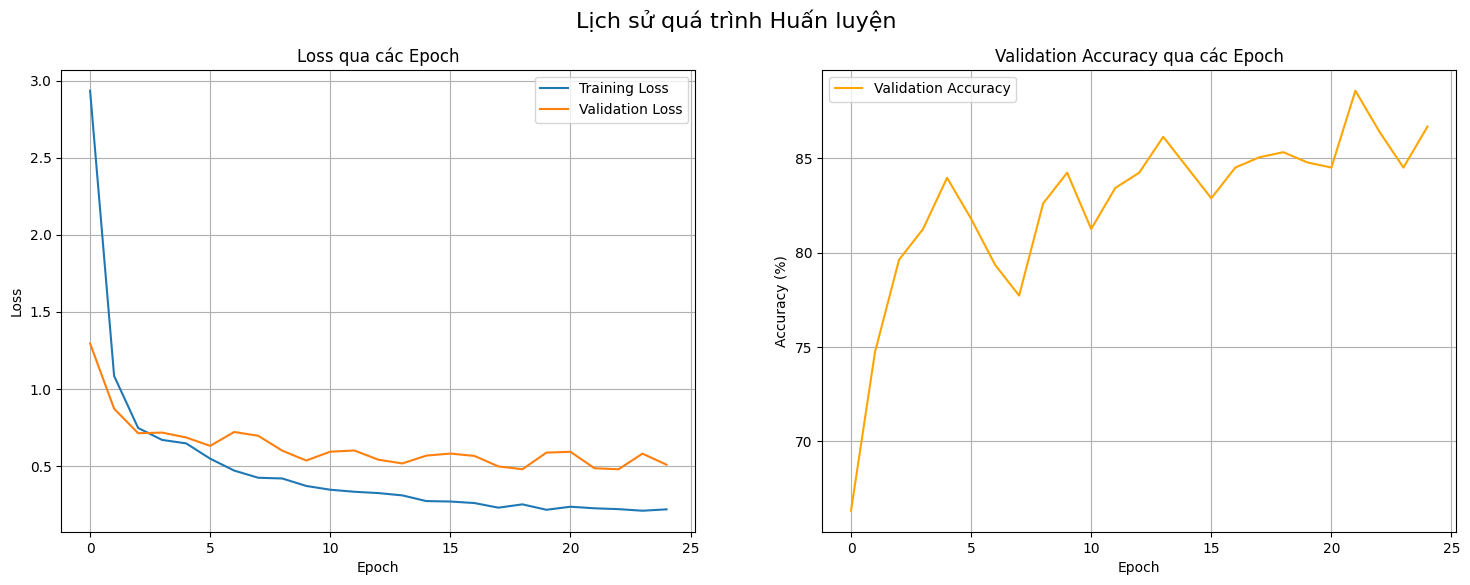


--- Chuẩn bị các bộ dữ liệu Test ---

----------------------- Đánh giá hiệu suất phân loại ID ------------------------


Lấy dự đoán từ tập Test ID:   0%|          | 0/115 [00:00<?, ?it/s]


============== KẾT QUẢ PHÂN LOẠI ID ==============
  Accuracy:  90.49%
  Precision: 90.61%
  Recall:    90.44%
  F1-Score:  90.36%

Đang vẽ Ma trận nhầm lẫn (Confusion Matrix)...


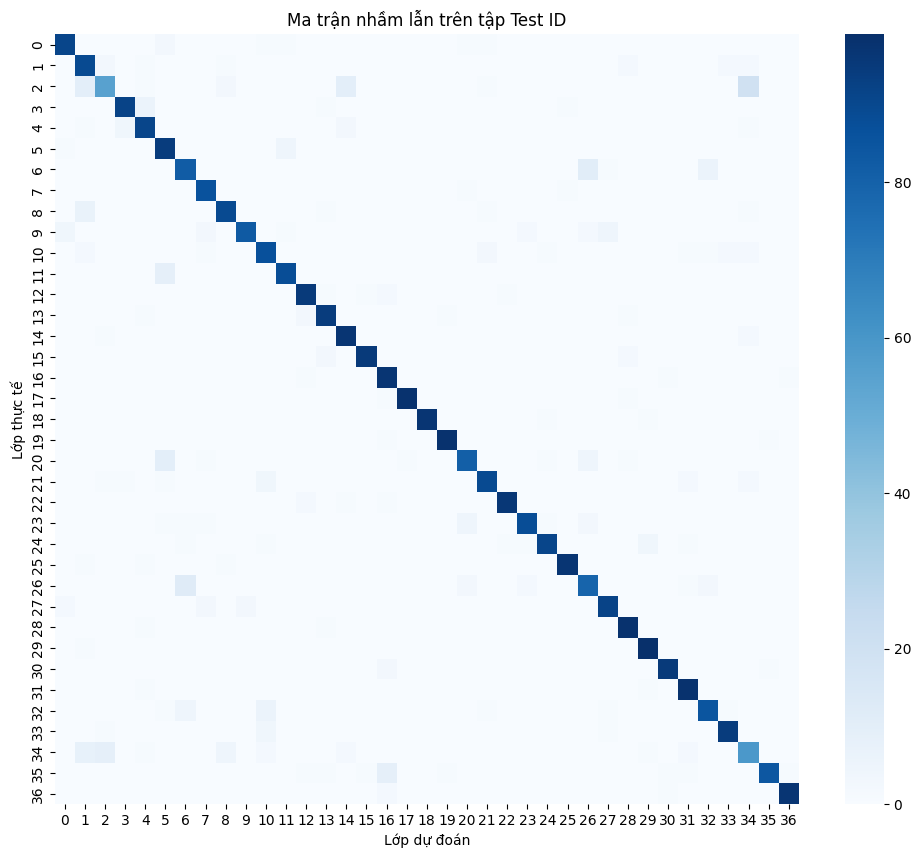


----------------------- Đánh giá hiệu suất phát hiện OOD -----------------------

Đang vẽ các đường cong đánh giá OOD...


Lấy điểm OOD:   0%|          | 0/115 [00:00<?, ?it/s]

Lấy điểm OOD:   0%|          | 0/200 [00:00<?, ?it/s]

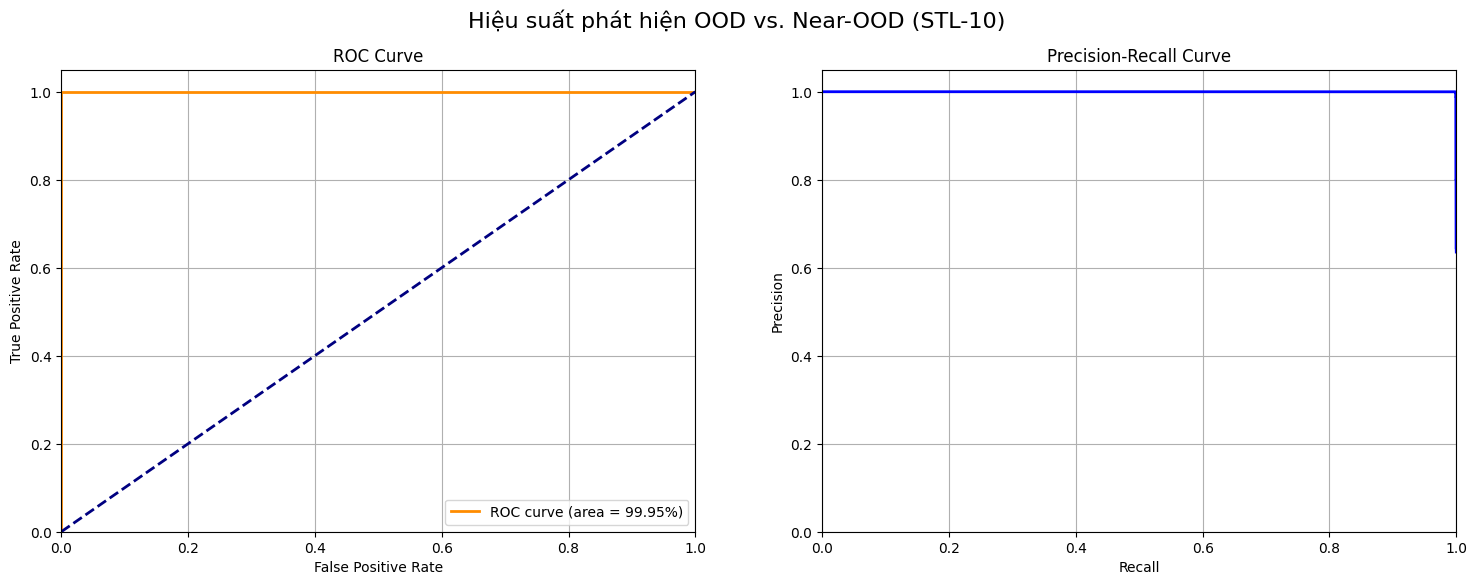

Lấy điểm OOD:   0%|          | 0/814 [00:00<?, ?it/s]

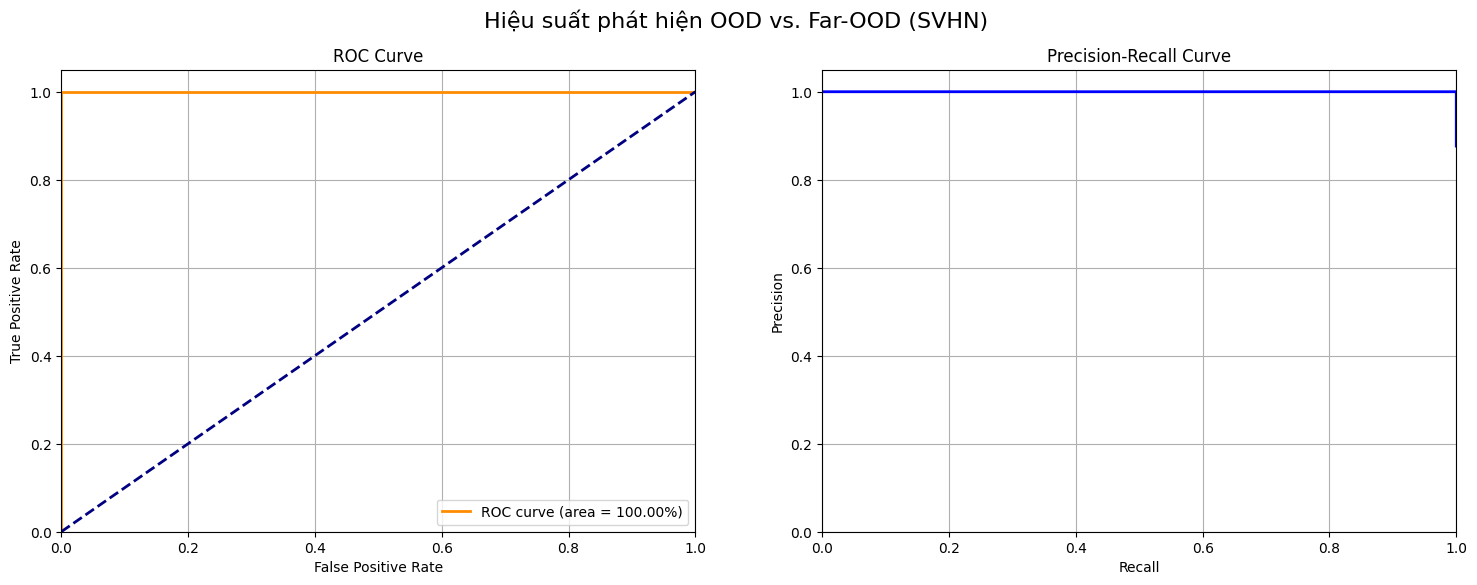


====================== BƯỚC 5: DEMO TƯƠNG TÁC VỚI GRADIO =======================
Đang tính toán ngưỡng OOD từ tập validation...


Lấy điểm OOD:   0%|          | 0/12 [00:00<?, ?it/s]

Ngưỡng OOD (feature norm) được xác định là: 1.1421

🚀 Khởi chạy ứng dụng Gradio...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://363eb45c32ca0bbf84.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ==============================================================================
# BƯỚC 0: CÀI ĐẶT MÔI TRƯỜNG
# ==============================================================================
print(" BƯỚC 0: CÀI ĐẶT MÔI TRƯỜNG ".center(80, "="))
!pip install -q diffusers transformers accelerate pandas scikit-learn gradio torchmetrics

import os, gc, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
import warnings; warnings.filterwarnings("ignore")
import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F, torchvision
import torchvision.models as models, torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Dataset, ConcatDataset, Subset
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc, confusion_matrix
import gradio as gr
import torchmetrics

# --- THIẾT LẬP CÁC THAM SỐ VÀ CẤU HÌNH CHUNG ---
torch.manual_seed(42); np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nSử dụng thiết bị: {DEVICE}")
from google.colab import drive
drive.mount('/content/gdrive')

SAVE_DIR = "/content/gdrive/MyDrive/Pet_OOD_Project_Contrastive_Final"
os.makedirs(SAVE_DIR, exist_ok=True)
OOD_MODEL_SAVE_PATH = os.path.join(SAVE_DIR, 'pet_ood_model_contrastive.pt')
DREAM_OOD_PATH = os.path.join(SAVE_DIR, 'dream_ood_1000_samples.npy')
print(f"Sử dụng thư mục làm việc: {SAVE_DIR}")

# ==============================================================================
# BƯỚC 1: CHUẨN BỊ DỮ LIỆU
# ==============================================================================
print("\n" + " BƯỚC 1: CHUẨN BỊ DỮ LIỆU ".center(80, "="))
# --- 1.1. TẠO/TẢI DREAMOOD ---
class DreamOODGenerator:
    def __init__(self, model_name="runwayml/stable-diffusion-v1-5"):
        from diffusers import StableDiffusionPipeline
        print(f"Đang tải model Stable Diffusion: {model_name}...");
        self.pipe = StableDiffusionPipeline.from_pretrained(model_name, torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32)
        if torch.cuda.is_available(): self.pipe.to("cuda")
        self.ood_prompts = ["abstract geometric patterns", "random noise texture"]

    def create_ood_dataset(self, num_samples=1000, save_path=None):
        print(f"Đang tạo {num_samples} mẫu Far-OOD...");
        batch_size = 16; num_batches = (num_samples + batch_size - 1) // batch_size
        all_images = np.concatenate([self.generate_ood_batch(min(batch_size, num_samples - i * batch_size)) for i in tqdm(range(num_batches), desc="Generating DreamOOD")])
        if save_path: np.save(save_path, all_images); print(f"Đã lưu DreamOOD dataset tại: {save_path}")
        return all_images

    def generate_ood_batch(self, batch_size=8, size=(224, 224)):
        images = []; prompts = [f"{np.random.choice(['vibrant','muted'])} {np.random.choice(self.ood_prompts)}" for _ in range(batch_size)]
        with torch.no_grad():
            generated_images = self.pipe(prompts, num_inference_steps=20, height=512, width=512, guidance_scale=7.5, safety_checker=None).images
            for img in generated_images: images.append(np.array(img.resize(size)))
        return np.array(images)

class DreamOODDataset(Dataset):
    def __init__(self, images, transform=None):
        self.images = images
        self.transform = transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        image = Image.fromarray(self.images[idx].astype(np.uint8))
        if self.transform:
            image = self.transform(image)
        return image, -1

if not os.path.exists(DREAM_OOD_PATH):
    dream_generator = DreamOODGenerator(); dream_ood_images = dream_generator.create_ood_dataset(num_samples=1000, save_path=DREAM_OOD_PATH)
    del dream_generator, dream_ood_images; gc.collect(); torch.cuda.empty_cache()
else: print("Tải DreamOOD dataset đã có...")

# --- 1.2. ĐỊNH NGHĨA BIẾN ĐỔI VÀ TẢI DATASET ---
data_transforms = {
    'train': transforms.Compose([transforms.RandomResizedCrop(224), transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]),
    'val': transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
}
id_dataset_full = torchvision.datasets.OxfordIIITPet(root='.', split='trainval', download=True, transform=data_transforms['train'])
train_size = int(0.9 * len(id_dataset_full)); val_size = len(id_dataset_full) - train_size
id_train_dataset, id_val_dataset = random_split(id_dataset_full, [train_size, val_size])
id_val_dataset.dataset.transform = data_transforms['val']
class_names = id_dataset_full.classes; num_classes = len(class_names)
near_ood_dataset_full = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=data_transforms['train'])
non_pet_indices = [i for i, label in enumerate(near_ood_dataset_full.labels) if near_ood_dataset_full.classes[label] not in ['cat', 'dog']]
near_ood_dataset = Subset(near_ood_dataset_full, non_pet_indices)
far_ood_images = np.load(DREAM_OOD_PATH); far_ood_dataset = DreamOODDataset(far_ood_images, transform=data_transforms['train'])
ood_train_dataset = ConcatDataset([near_ood_dataset, far_ood_dataset])
id_train_loader = DataLoader(id_train_dataset, batch_size=32, shuffle=True, num_workers=2);
id_val_loader = DataLoader(id_val_dataset, batch_size=32, shuffle=False, num_workers=2);
ood_train_loader = DataLoader(ood_train_dataset, batch_size=32, shuffle=True, num_workers=2)

# ==============================================================================
# BƯỚC 2: ĐỊNH NGHĨA MODEL VÀ LOSS
# ==============================================================================
print("\n" + " BƯỚC 2: ĐỊNH NGHĨA MODEL VÀ LOSS ".center(80, "="))
class ProjectionHead(nn.Module):
    def __init__(self, in_features, projection_dim=128):
        super().__init__()
        self.projection = nn.Sequential(nn.Linear(in_features, in_features, bias=False), nn.ReLU(), nn.Linear(in_features, projection_dim, bias=False))
    def forward(self, x):
        return self.projection(x) # Bỏ normalize

class OODResNet18(nn.Module):
    def __init__(self, num_classes, projection_dim=128):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.projection_head = ProjectionHead(self.backbone_dim, projection_dim)
        self.classifier = nn.Linear(self.backbone_dim, num_classes)
    def forward(self, x, return_features=False):
        backbone_features = self.backbone(x)
        logits = self.classifier(backbone_features)
        if return_features:
            projected_features = self.projection_head(backbone_features)
            return logits, backbone_features, projected_features
        return logits

class ContrastiveSeparationLossV2(nn.Module):
    def __init__(self, id_target_norm=1.0, ood_margin=5.0):
        super().__init__()
        self.id_target_norm = id_target_norm
        self.ood_margin = ood_margin
    def forward(self, id_features, ood_features):
        loss_id = torch.pow(torch.norm(id_features, p=2, dim=1) - self.id_target_norm, 2).mean()
        loss_ood = F.relu(self.ood_margin - torch.norm(ood_features, p=2, dim=1)).mean()
        return loss_id + loss_ood

model_ood = OODResNet18(num_classes=num_classes).to(DEVICE)

# ==============================================================================
# BƯỚC 3: HUẤN LUYỆN HOẶC TẢI MODEL
# ==============================================================================
if os.path.exists(OOD_MODEL_SAVE_PATH):
    print("\n" + " ĐÃ TÌM THẤY MODEL ĐÃ HUẤN LUYỆN, TẢI TRỰC TIẾP... ".center(80, "="))
    model_ood.load_state_dict(torch.load(OOD_MODEL_SAVE_PATH, map_location=DEVICE))
    history = None
else:
    print("\n" + " BƯỚC 3: BẮT ĐẦU HUẤN LUYỆN MODEL CONTRASTIVE LOSS ".center(80, "="))
    epochs = 25; lr = 1e-4; contrastive_weight = 0.5
    optimizer = optim.AdamW(model_ood.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    cls_criterion = nn.CrossEntropyLoss(); contrastive_criterion = ContrastiveSeparationLossV2()
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(epochs):
        model_ood.train(); ood_iter = iter(ood_train_loader); running_train_loss = 0.0
        progress_bar = tqdm(id_train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for id_inputs, id_targets in progress_bar:
            id_inputs, id_targets = id_inputs.to(DEVICE), id_targets.to(DEVICE)
            try: ood_inputs, _ = next(ood_iter)
            except StopIteration: ood_iter = iter(ood_train_loader); ood_inputs, _ = next(ood_iter)
            ood_inputs = ood_inputs.to(DEVICE); optimizer.zero_grad()
            all_inputs = torch.cat([id_inputs, ood_inputs]); logits, _, projected_features = model_ood(all_inputs, return_features=True)
            id_logits = logits[:len(id_inputs)]; id_projected_features = projected_features[:len(id_inputs)]; ood_projected_features = projected_features[len(id_inputs):]
            loss_cls = cls_criterion(id_logits, id_targets); loss_contrastive = contrastive_criterion(id_projected_features, ood_projected_features)
            total_loss = loss_cls + contrastive_weight * loss_contrastive
            total_loss.backward(); optimizer.step(); running_train_loss += total_loss.item()
            progress_bar.set_postfix(loss=f"{total_loss.item():.4f}")
        model_ood.eval(); val_correct, val_total, running_val_loss = 0, 0, 0.0
        with torch.no_grad():
            for inputs, targets in id_val_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE); outputs = model_ood(inputs); loss = cls_criterion(outputs, targets); running_val_loss += loss.item(); _, predicted = torch.max(outputs.data, 1); val_total += targets.size(0); val_correct += (predicted == targets).sum().item()
        epoch_train_loss = running_train_loss / len(id_train_loader); epoch_val_loss = running_val_loss / len(id_val_loader); epoch_val_acc = 100 * val_correct / val_total
        history['train_loss'].append(epoch_train_loss); history['val_loss'].append(epoch_val_loss); history['val_acc'].append(epoch_val_acc)
        print(f"Epoch {epoch+1:02d}: Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")
        scheduler.step()
        if epoch_val_acc > best_val_acc: torch.save(model_ood.state_dict(), OOD_MODEL_SAVE_PATH); best_val_acc = epoch_val_acc
    model_ood.load_state_dict(torch.load(OOD_MODEL_SAVE_PATH))

# ==============================================================================
# BƯỚC 4: BẢNG ĐIỀU KHIỂN ĐÁNH GIÁ TOÀN DIỆN
# ==============================================================================
print("\n" + " BƯỚC 4: BẢNG ĐIỀU KHIỂN ĐÁNH GIÁ TOÀN DIỆN ".center(80, "="))
# (Phần code đánh giá giống hệt như phiên bản trước, không cần thay đổi)
# ... (dán lại cho đầy đủ)
def plot_training_history(history):
    if history is None: print("Không có lịch sử huấn luyện để vẽ đồ thị (model đã được tải từ file)."); return
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6)); fig.suptitle('Lịch sử quá trình Huấn luyện', fontsize=16)
    ax1.plot(history['train_loss'], label='Training Loss'); ax1.plot(history['val_loss'], label='Validation Loss'); ax1.set_title('Loss qua các Epoch'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.grid(True)
    ax2.plot(history['val_acc'], label='Validation Accuracy', color='orange'); ax2.set_title('Validation Accuracy qua các Epoch'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)'); ax2.legend(); ax2.grid(True)
    plt.show()
plot_training_history(history)
print("\n--- Chuẩn bị các bộ dữ liệu Test ---")
batch_size = 32
id_test_dataset = torchvision.datasets.OxfordIIITPet(root='.', split='test', download=True, transform=data_transforms['val'])
id_test_loader = DataLoader(id_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
near_ood_test_full = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=data_transforms['val'])
non_pet_indices_test = [i for i, label in enumerate(near_ood_test_full.labels) if near_ood_test_full.classes[label] not in ['cat', 'dog']]
near_ood_test_dataset = Subset(near_ood_test_full, non_pet_indices_test)
near_ood_test_loader = DataLoader(near_ood_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
far_ood_test_dataset = torchvision.datasets.SVHN(root='./data', split='test', download=True, transform=data_transforms['val'])
far_ood_test_loader = DataLoader(far_ood_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
print("\n" + " Đánh giá hiệu suất phân loại ID ".center(80, "-"))
model_ood.eval(); all_preds = torch.tensor([]).to(DEVICE); all_labels = torch.tensor([]).to(DEVICE)
with torch.no_grad():
    for inputs, targets in tqdm(id_test_loader, desc="Lấy dự đoán từ tập Test ID"):
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE); outputs = model_ood(inputs); _, predicted = torch.max(outputs.data, 1); all_preds = torch.cat((all_preds, predicted)); all_labels = torch.cat((all_labels, targets))
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes).to(DEVICE)
precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro').to(DEVICE)
recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro').to(DEVICE)
f1_score = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro').to(DEVICE)
print("\n" + " KẾT QUẢ PHÂN LOẠI ID ".center(50, "=")); print(f"  Accuracy:  {accuracy(all_preds, all_labels).item():.2%}"); print(f"  Precision: {precision(all_preds, all_labels).item():.2%}"); print(f"  Recall:    {recall(all_preds, all_labels).item():.2%}"); print(f"  F1-Score:  {f1_score(all_preds, all_labels).item():.2%}"); print("="*50)
print("\nĐang vẽ Ma trận nhầm lẫn (Confusion Matrix)...")
cm = confusion_matrix(all_labels.cpu().numpy(), all_preds.cpu().numpy())
plt.figure(figsize=(12, 10)); sns.heatmap(cm, annot=False, fmt='d', cmap='Blues'); plt.title('Ma trận nhầm lẫn trên tập Test ID'); plt.ylabel('Lớp thực tế'); plt.xlabel('Lớp dự đoán'); plt.show()
print("\n" + " Đánh giá hiệu suất phát hiện OOD ".center(80, "-"))
def get_contrastive_scores(model, loader):
    all_scores = []; model.eval()
    with torch.no_grad():
        for inputs, _ in tqdm(loader, desc="Lấy điểm OOD", leave=False):
            _, _, projected_features = model(inputs.to(DEVICE), return_features=True); scores = torch.norm(projected_features, p=2, dim=1); all_scores.extend(scores.cpu().numpy())
    return np.array(all_scores)
def plot_ood_curves(id_scores, ood_scores, ood_name):
    labels = np.concatenate([np.zeros_like(id_scores), np.ones_like(ood_scores)]); scores = np.concatenate([id_scores, ood_scores])
    fpr, tpr, _ = roc_curve(labels, scores); roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(labels, scores)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6)); fig.suptitle(f'Hiệu suất phát hiện OOD vs. {ood_name}', fontsize=16)
    ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2%})'); ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--'); ax1.set_xlim([0.0, 1.0]); ax1.set_ylim([0.0, 1.05]); ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate'); ax1.set_title('ROC Curve'); ax1.legend(loc="lower right"); ax1.grid(True)
    ax2.plot(recall, precision, color='blue', lw=2); ax2.set_xlim([0.0, 1.0]); ax2.set_ylim([0.0, 1.05]); ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision'); ax2.set_title('Precision-Recall Curve'); ax2.grid(True)
    plt.show()
print("\nĐang vẽ các đường cong đánh giá OOD...")
id_test_scores = get_contrastive_scores(model_ood, id_test_loader)
plot_ood_curves(id_test_scores, get_contrastive_scores(model_ood, near_ood_test_loader), "Near-OOD (STL-10)")
plot_ood_curves(id_test_scores, get_contrastive_scores(model_ood, far_ood_test_loader), "Far-OOD (SVHN)")
del id_test_loader, near_ood_test_loader, far_ood_test_loader; gc.collect()

# ==============================================================================
# BƯỚC 5: DEMO TƯƠNG TÁC VỚI GRADIO
# ==============================================================================
# (Phần này không thay đổi)
print("\n" + " BƯỚC 5: DEMO TƯƠNG TÁC VỚI GRADIO ".center(80, "="))
print("Đang tính toán ngưỡng OOD từ tập validation...")
id_val_scores = get_contrastive_scores(model_ood, id_val_loader)
OOD_THRESHOLD = np.percentile(id_val_scores, 95)
print(f"Ngưỡng OOD (feature norm) được xác định là: {OOD_THRESHOLD:.4f}")
def predict_gradio(image):
    if image is None: return "Vui lòng tải ảnh lên.", "N/A", "N/A", "N/A"
    pil_image = Image.fromarray(image).convert("RGB"); img_tensor = data_transforms['val'](pil_image).unsqueeze(0).to(DEVICE)
    model_ood.eval()
    with torch.no_grad():
        logits, _, projected_features = model_ood(img_tensor, return_features=True)
        ood_score = torch.norm(projected_features, p=2, dim=1).item()
    is_ood = ood_score > OOD_THRESHOLD; score_info = f"Score: {ood_score:.4f} (Ngưỡng: {OOD_THRESHOLD:.4f})"
    if is_ood: return "🚨 **KHÔNG PHẢI CHÓ/MÈO (OOD)**", "N/A", "N/A", score_info
    else:
        probs = F.softmax(logits, dim=1)[0]; confidence, pred_idx = torch.max(probs, 0)
        predicted_class = class_names[pred_idx.item()].replace("_", " ").title()
        return f"✅ **Là chó/mèo (In-Distribution)**", predicted_class, f"{confidence.item():.2%}", score_info
with gr.Blocks(title="🐾 OOD Pet Detection (Contrastive)", theme=gr.themes.Soft()) as app:
    gr.Markdown("# 🐾 Phát hiện Chó/Mèo với Contrastive Loss");
    with gr.Row():
        with gr.Column(scale=1): image_input = gr.Image(label="📸 Tải ảnh lên", type="numpy"); predict_btn = gr.Button("🚀 Phân tích ảnh", variant="primary")
        with gr.Column(scale=1): status_output = gr.Markdown(label="📊 Kết quả"); class_output = gr.Textbox(label="🏷️ Giống"); confidence_output = gr.Textbox(label="🎯 Độ chắc chắn"); score_output = gr.Textbox(label="📈 Điểm OOD")
    predict_btn.click(fn=predict_gradio, inputs=image_input, outputs=[status_output, class_output, confidence_output, score_output])
print("\n🚀 Khởi chạy ứng dụng Gradio...")
app.launch(share=True, debug=True)

========================== BƯỚC 0: CÀI ĐẶT MÔI TRƯỜNG ==========================

Sử dụng thiết bị: cuda
Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Thư mục làm việc của dự án: /content/gdrive/MyDrive/Pet_OOD_Experiments/Contrastive_Loss
Dữ liệu sẽ được lưu tại: /content/gdrive/MyDrive/Pet_OOD_Experiments/Contrastive_Loss/data

=========================== BƯỚC 1: CHUẨN BỊ DỮ LIỆU ===========================
Tải DreamOOD dataset đã có từ /content/gdrive/MyDrive/Pet_OOD_Experiments/Contrastive_Loss/data/dream_ood_1000_samples.npy


100%|██████████| 792M/792M [00:43<00:00, 18.2MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.3MB/s]
100%|██████████| 2.64G/2.64G [21:55<00:00, 2.01MB/s]



======================= BƯỚC 2: ĐỊNH NGHĨA MODEL VÀ LOSS =======================
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]



============== BƯỚC 3: BẮT ĐẦU HUẤN LUYỆN MODEL CONTRASTIVE LOSS ===============


...

Epoch 30: Train Loss: 0.2457, Val Loss: 0.6015, Val Acc: 83.97%
EarlyStopping counter: 8 / 10


Epoch 31/100:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 31: Train Loss: 0.2264, Val Loss: 0.6320, Val Acc: 82.61%
EarlyStopping counter: 9 / 10


Epoch 32/100:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 32: Train Loss: 0.2301, Val Loss: 0.5748, Val Acc: 83.70%
EarlyStopping counter: 10 / 10
Early stopping triggered.

--- HUẤN LUYỆN HOÀN TẤT ---
Tải model tốt nhất từ: /content/gdrive/MyDrive/Pet_OOD_Experiments/Contrastive_Loss/best_contrastive_model.pt

================== BƯỚC 4: BẢNG ĐIỀU KHIỂN ĐÁNH GIÁ TOÀN DIỆN ==================


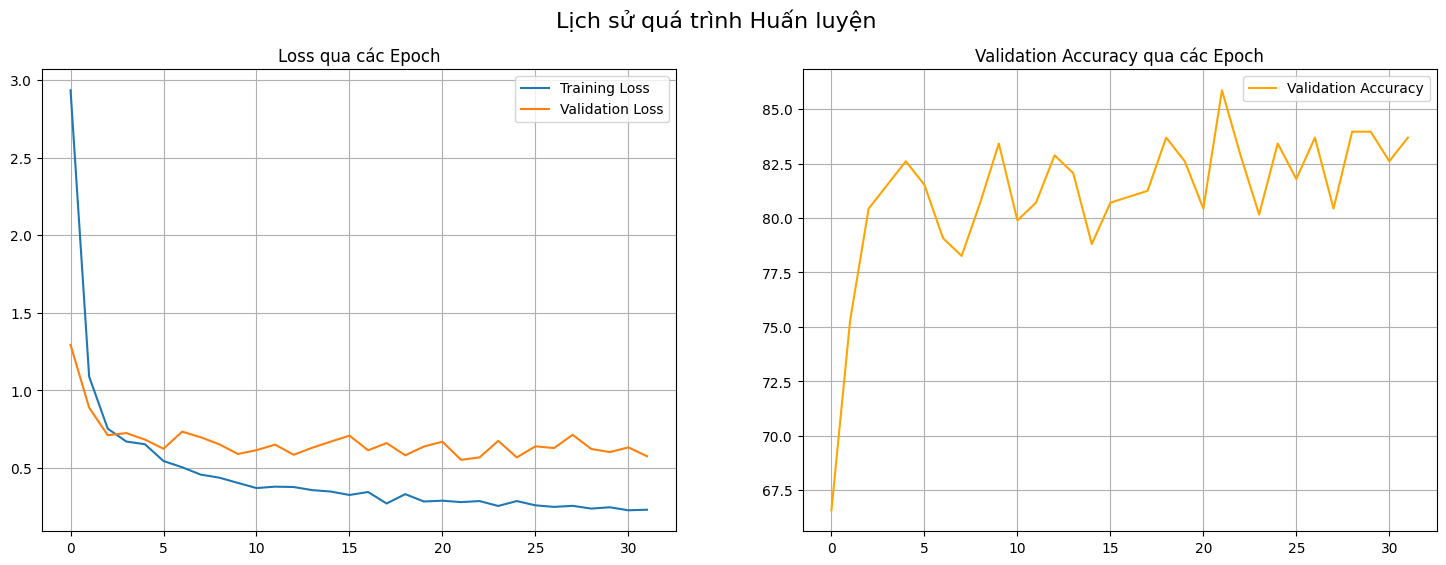


--- Chuẩn bị các bộ dữ liệu Test ---


100%|██████████| 64.3M/64.3M [00:13<00:00, 4.60MB/s]



-------------------- Đánh giá hiệu suất phân loại ID (phụ) ---------------------


Lấy dự đoán từ tập Test ID:   0%|          | 0/115 [00:00<?, ?it/s]


============== KẾT QUẢ PHÂN LOẠI ID ==============
  Accuracy: 88.44%
  F1-Score: 88.34%

----------------- Đánh giá hiệu suất phát hiện ID/OOD (chính) ------------------


Lấy điểm OOD:   0%|          | 0/115 [00:00<?, ?it/s]

Lấy điểm OOD:   0%|          | 0/200 [00:00<?, ?it/s]

Lấy điểm OOD:   0%|          | 0/814 [00:00<?, ?it/s]


Đang tính toán ngưỡng và vẽ đồ thị phân phối điểm OOD...


Lấy điểm OOD:   0%|          | 0/12 [00:00<?, ?it/s]

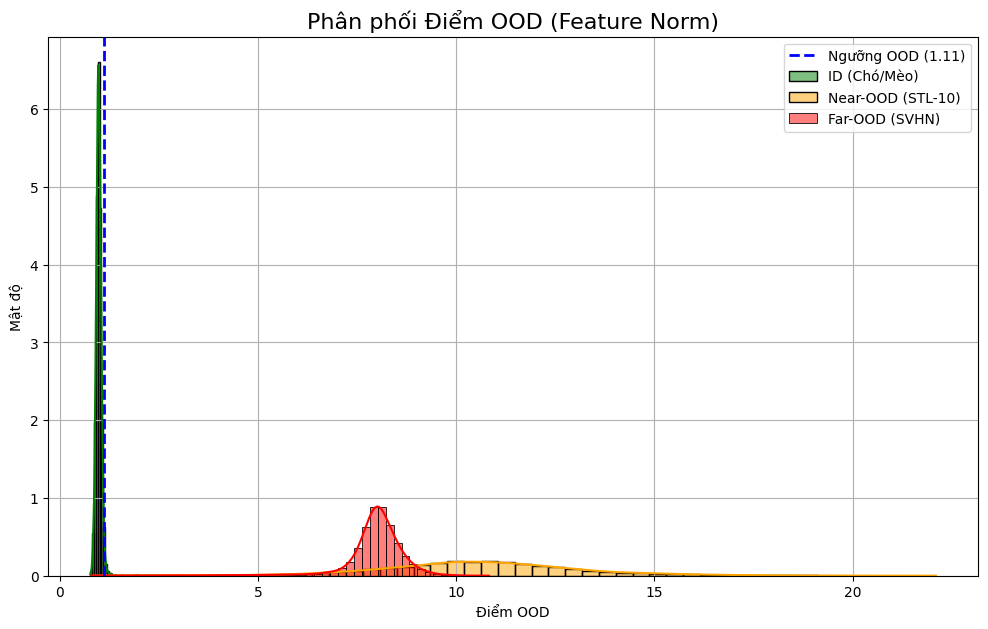


Đang vẽ các đường cong ROC...
Kết quả với Near-OOD (STL-10): AUROC = 99.95%


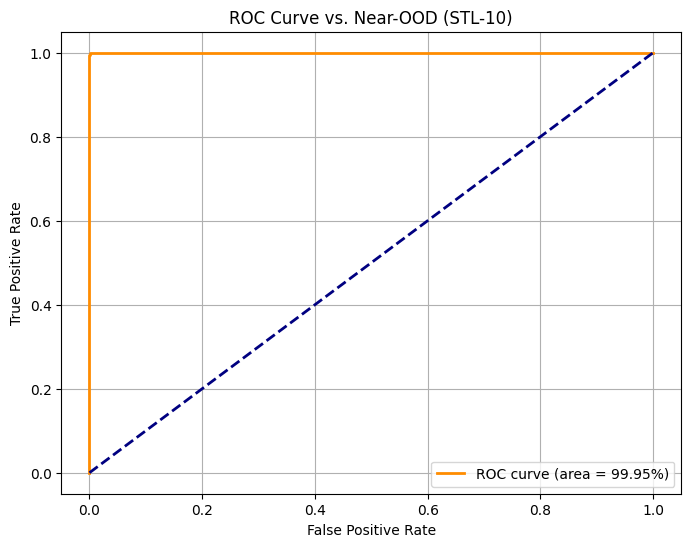

Kết quả với Far-OOD (SVHN): AUROC = 99.95%


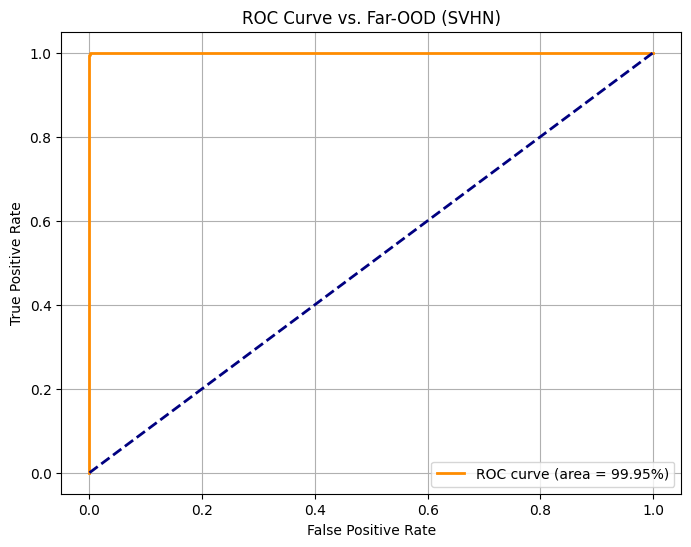


====================== BƯỚC 5: DEMO TƯƠNG TÁC VỚI GRADIO =======================
Ngưỡng OOD (feature norm) được xác định là: 1.1055

🚀 Khởi chạy ứng dụng Gradio...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://0a910e6c9cbd0cca14.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://0a910e6c9cbd0cca14.gradio.live


In [ ]:
# ==============================================================================
# BƯỚC 0: CÀI ĐẶT MÔI TRƯỜNG
# ==============================================================================
print(" BƯỚC 0: CÀI ĐẶT MÔI TRƯỜNG ".center(80, "="))
!pip install -q diffusers transformers accelerate pandas scikit-learn gradio torchmetrics

import os, gc, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
import warnings; warnings.filterwarnings("ignore")
import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F, torchvision
import torchvision.models as models, torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Dataset, ConcatDataset, Subset
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc
import gradio as gr
import torchmetrics

# --- THIẾT LẬP CÁC THAM SỐ VÀ CẤU HÌNH CHUNG ---
torch.manual_seed(42); np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nSử dụng thiết bị: {DEVICE}")
from google.colab import drive
drive.mount('/content/gdrive')

BASE_DIR = "/content/gdrive/MyDrive/Pet_OOD_Experiments"
SAVE_DIR = os.path.join(BASE_DIR, "Contrastive_Loss")
DATA_DIR = os.path.join(SAVE_DIR, "data")
os.makedirs(DATA_DIR, exist_ok=True)
OOD_MODEL_SAVE_PATH = os.path.join(SAVE_DIR, 'best_contrastive_model.pt')
DREAM_OOD_PATH = os.path.join(DATA_DIR, 'dream_ood_1000_samples.npy')
print(f"Thư mục làm việc của dự án: {SAVE_DIR}")
print(f"Dữ liệu sẽ được lưu tại: {DATA_DIR}")

# ==============================================================================
# BƯỚC 1: CHUẨN BỊ DỮ LIỆU
# ==============================================================================
print("\n" + " BƯỚC 1: CHUẨN BỊ DỮ LIỆU ".center(80, "="))
class DreamOODGenerator:
    def __init__(self, model_name="runwayml/stable-diffusion-v1-5"):
        from diffusers import StableDiffusionPipeline
        self.pipe = StableDiffusionPipeline.from_pretrained(model_name, torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32)
        if torch.cuda.is_available(): self.pipe.to("cuda")
        self.ood_prompts = ["abstract geometric patterns", "random noise texture"]
    def create_ood_dataset(self, num_samples=1000, save_path=None):
        batch_size = 16; num_batches = (num_samples + batch_size - 1) // batch_size
        all_images = np.concatenate([self.generate_ood_batch(min(batch_size, num_samples - i * batch_size)) for i in tqdm(range(num_batches), desc="Generating DreamOOD")])
        if save_path: np.save(save_path, all_images)
        return all_images
    def generate_ood_batch(self, batch_size=8, size=(224, 224)):
        images = []; prompts = [f"{np.random.choice(['vibrant','muted'])} {np.random.choice(self.ood_prompts)}" for _ in range(batch_size)]
        with torch.no_grad():
            generated_images = self.pipe(prompts, num_inference_steps=20, height=512, width=512, guidance_scale=7.5, safety_checker=None).images
            for img in generated_images: images.append(np.array(img.resize(size)))
        return np.array(images)

class DreamOODDataset(Dataset):
    # [SỬA LỖI] Định dạng lại các hàm cho đúng cú pháp Python
    def __init__(self, images, transform=None):
        self.images = images
        self.transform = transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        image = Image.fromarray(self.images[idx].astype(np.uint8))
        if self.transform:
            image = self.transform(image)
        return image, -1

if not os.path.exists(DREAM_OOD_PATH):
    print(f"Tạo file DreamOOD tại {DREAM_OOD_PATH}...")
    dream_generator = DreamOODGenerator(); dream_ood_images = dream_generator.create_ood_dataset(num_samples=1000, save_path=DREAM_OOD_PATH)
    del dream_generator, dream_ood_images; gc.collect(); torch.cuda.empty_cache()
else: print(f"Tải DreamOOD dataset đã có từ {DREAM_OOD_PATH}")

data_transforms = {
    'train': transforms.Compose([transforms.RandomResizedCrop(224), transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]),
    'val': transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
}
id_dataset_full = torchvision.datasets.OxfordIIITPet(root=DATA_DIR, split='trainval', download=True, transform=data_transforms['train'])
train_size = int(0.9 * len(id_dataset_full)); val_size = len(id_dataset_full) - train_size
id_train_dataset, id_val_dataset = random_split(id_dataset_full, [train_size, val_size])
id_val_dataset.dataset.transform = data_transforms['val']
class_names = id_dataset_full.classes; num_classes = len(class_names)
near_ood_dataset_full = torchvision.datasets.STL10(root=DATA_DIR, split='train', download=True, transform=data_transforms['train'])
non_pet_indices = [i for i, label in enumerate(near_ood_dataset_full.labels) if near_ood_dataset_full.classes[label] not in ['cat', 'dog']]
near_ood_dataset = Subset(near_ood_dataset_full, non_pet_indices)
far_ood_images = np.load(DREAM_OOD_PATH); far_ood_dataset = DreamOODDataset(far_ood_images, transform=data_transforms['train'])
ood_train_dataset = ConcatDataset([near_ood_dataset, far_ood_dataset])
id_train_loader = DataLoader(id_train_dataset, batch_size=32, shuffle=True, num_workers=2);
id_val_loader = DataLoader(id_val_dataset, batch_size=32, shuffle=False, num_workers=2);
ood_train_loader = DataLoader(ood_train_dataset, batch_size=32, shuffle=True, num_workers=2)

# ==============================================================================
# BƯỚC 2: ĐỊNH NGHĨA MODEL VÀ LOSS
# ==============================================================================
print("\n" + " BƯỚC 2: ĐỊNH NGHĨA MODEL VÀ LOSS ".center(80, "="))
class ProjectionHead(nn.Module):
    def __init__(self, in_features, projection_dim=128):
        super().__init__()
        self.projection = nn.Sequential(nn.Linear(in_features, in_features, bias=False), nn.ReLU(), nn.Linear(in_features, projection_dim, bias=False))
    def forward(self, x):
        return self.projection(x)
class OODResNet18(nn.Module):
    def __init__(self, num_classes, projection_dim=128):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.projection_head = ProjectionHead(self.backbone_dim, projection_dim)
        self.classifier = nn.Linear(self.backbone_dim, num_classes)
    def forward(self, x, return_features=False):
        backbone_features = self.backbone(x)
        logits = self.classifier(backbone_features)
        if return_features:
            projected_features = self.projection_head(backbone_features)
            return logits, backbone_features, projected_features
        return logits
class ContrastiveSeparationLossV2(nn.Module):
    def __init__(self, id_target_norm=1.0, ood_margin=5.0):
        super().__init__()
        self.id_target_norm = id_target_norm
        self.ood_margin = ood_margin
    def forward(self, id_features, ood_features):
        loss_id = torch.pow(torch.norm(id_features, p=2, dim=1) - self.id_target_norm, 2).mean()
        loss_ood = F.relu(self.ood_margin - torch.norm(ood_features, p=2, dim=1)).mean()
        return loss_id + loss_ood
model_ood = OODResNet18(num_classes=num_classes).to(DEVICE)

# ==============================================================================
# BƯỚC 3: HUẤN LUYỆN VỚI EARLY STOPPING
# ==============================================================================
class EarlyStopping:
    def __init__(self, patience=10, verbose=True, delta=0, path='checkpoint.pt'):
        self.patience = patience; self.verbose = verbose; self.delta = delta; self.path = path
        self.counter = 0; self.best_score = None; self.early_stop = False; self.val_loss_min = np.Inf
    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None: self.best_score = score; self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose: print(f'EarlyStopping counter: {self.counter} / {self.patience}')
            if self.counter >= self.patience: self.early_stop = True
        else:
            self.best_score = score; self.save_checkpoint(val_loss, model); self.counter = 0
    def save_checkpoint(self, val_loss, model):
        if self.verbose: print(f'Validation loss decreased ({self.val_loss_min:.4f} --> {val_loss:.4f}). Saving model...')
        torch.save(model.state_dict(), self.path); self.val_loss_min = val_loss

if os.path.exists(OOD_MODEL_SAVE_PATH):
    print(f"Xóa model cũ tại {OOD_MODEL_SAVE_PATH} để huấn luyện lại.")
    os.remove(OOD_MODEL_SAVE_PATH)
print("\n" + " BƯỚC 3: BẮT ĐẦU HUẤN LUYỆN MODEL CONTRASTIVE LOSS ".center(80, "="))
epochs = 100; lr = 1e-4; contrastive_weight = 0.5
optimizer = optim.AdamW(model_ood.parameters(), lr=lr, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
cls_criterion = nn.CrossEntropyLoss(); contrastive_criterion = ContrastiveSeparationLossV2()
early_stopping = EarlyStopping(patience=10, verbose=True, path=OOD_MODEL_SAVE_PATH)
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
for epoch in range(epochs):
    model_ood.train(); ood_iter = iter(ood_train_loader); running_train_loss = 0.0
    progress_bar = tqdm(id_train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for id_inputs, id_targets in progress_bar:
        id_inputs, id_targets = id_inputs.to(DEVICE), id_targets.to(DEVICE)
        try: ood_inputs, _ = next(ood_iter)
        except StopIteration: ood_iter = iter(ood_train_loader); ood_inputs, _ = next(ood_iter)
        ood_inputs = ood_inputs.to(DEVICE); optimizer.zero_grad()
        all_inputs = torch.cat([id_inputs, ood_inputs]); logits, _, projected_features = model_ood(all_inputs, return_features=True)
        id_logits = logits[:len(id_inputs)]; id_projected_features = projected_features[:len(id_inputs)]; ood_projected_features = projected_features[len(id_inputs):]
        loss_cls = cls_criterion(id_logits, id_targets); loss_contrastive = contrastive_criterion(id_projected_features, ood_projected_features)
        total_loss = loss_cls + contrastive_weight * loss_contrastive
        total_loss.backward(); optimizer.step(); running_train_loss += total_loss.item()
        progress_bar.set_postfix(loss=f"{total_loss.item():.4f}")
    model_ood.eval(); val_correct, val_total, running_val_loss = 0, 0, 0.0
    with torch.no_grad():
        for inputs, targets in id_val_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE); outputs = model_ood(inputs); loss = cls_criterion(outputs, targets); running_val_loss += loss.item(); _, predicted = torch.max(outputs.data, 1); val_total += targets.size(0); val_correct += (predicted == targets).sum().item()
    epoch_train_loss = running_train_loss / len(id_train_loader); epoch_val_loss = running_val_loss / len(id_val_loader); epoch_val_acc = 100 * val_correct / val_total
    history['train_loss'].append(epoch_train_loss); history['val_loss'].append(epoch_val_loss); history['val_acc'].append(epoch_val_acc)
    print(f"Epoch {epoch+1:02d}: Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")
    scheduler.step()
    early_stopping(epoch_val_loss, model_ood)
    if early_stopping.early_stop: print("Early stopping triggered."); break
print("\n--- HUẤN LUYỆN HOÀN TẤT ---")
print(f"Tải model tốt nhất từ: {OOD_MODEL_SAVE_PATH}")
model_ood.load_state_dict(torch.load(OOD_MODEL_SAVE_PATH))

# ==============================================================================
# BƯỚC 4: BẢNG ĐIỀU KHIỂN ĐÁNH GIÁ TOÀN DIỆN
# ==============================================================================
# (Phần code này không thay đổi)
print("\n" + " BƯỚC 4: BẢNG ĐIỀU KHIỂN ĐÁNH GIÁ TOÀN DIỆN ".center(80, "="))
def plot_training_history(history):
    if history is None or not history['train_loss']: print("Không có lịch sử huấn luyện để vẽ đồ thị."); return
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6)); fig.suptitle('Lịch sử quá trình Huấn luyện', fontsize=16)
    ax1.plot(history['train_loss'], label='Training Loss'); ax1.plot(history['val_loss'], label='Validation Loss'); ax1.set_title('Loss qua các Epoch'); ax1.legend(); ax1.grid(True)
    ax2.plot(history['val_acc'], label='Validation Accuracy', color='orange'); ax2.set_title('Validation Accuracy qua các Epoch'); ax2.legend(); ax2.grid(True)
    plt.show()
plot_training_history(history)
print("\n--- Chuẩn bị các bộ dữ liệu Test ---")
batch_size = 32
id_test_dataset = torchvision.datasets.OxfordIIITPet(root=DATA_DIR, split='test', download=True, transform=data_transforms['val'])
id_test_loader = DataLoader(id_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
near_ood_test_full = torchvision.datasets.STL10(root=DATA_DIR, split='test', download=True, transform=data_transforms['val'])
non_pet_indices_test = [i for i, label in enumerate(near_ood_test_full.labels) if near_ood_test_full.classes[label] not in ['cat', 'dog']]
near_ood_test_dataset = Subset(near_ood_test_full, non_pet_indices_test)
near_ood_test_loader = DataLoader(near_ood_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
far_ood_test_dataset = torchvision.datasets.SVHN(root=DATA_DIR, split='test', download=True, transform=data_transforms['val'])
far_ood_test_loader = DataLoader(far_ood_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
print("\n" + " Đánh giá hiệu suất phân loại ID (phụ) ".center(80, "-"))
model_ood.eval(); all_preds = torch.tensor([]).to(DEVICE); all_labels = torch.tensor([]).to(DEVICE)
with torch.no_grad():
    for inputs, targets in tqdm(id_test_loader, desc="Lấy dự đoán từ tập Test ID"):
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE); outputs, _, _ = model_ood(inputs, return_features=True); _, predicted = torch.max(outputs.data, 1); all_preds = torch.cat((all_preds, predicted)); all_labels = torch.cat((all_labels, targets))
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes).to(DEVICE)
f1_score = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro').to(DEVICE)
print("\n" + " KẾT QUẢ PHÂN LOẠI ID ".center(50, "=")); print(f"  Accuracy: {accuracy(all_preds, all_labels).item():.2%}"); print(f"  F1-Score: {f1_score(all_preds, all_labels).item():.2%}"); print("="*50)
print("\n" + " Đánh giá hiệu suất phát hiện ID/OOD (chính) ".center(80, "-"))
def get_contrastive_scores(model, loader):
    all_scores = []; model.eval()
    with torch.no_grad():
        for inputs, _ in tqdm(loader, desc="Lấy điểm OOD", leave=False):
            _, _, projected_features = model(inputs.to(DEVICE), return_features=True); scores = torch.norm(projected_features, p=2, dim=1); all_scores.extend(scores.cpu().numpy())
    return np.array(all_scores)
id_test_scores = get_contrastive_scores(model_ood, id_test_loader)
near_ood_scores = get_contrastive_scores(model_ood, near_ood_test_loader)
far_ood_scores = get_contrastive_scores(model_ood, far_ood_test_loader)
def plot_score_distributions(id_scores, near_ood_scores, far_ood_scores, threshold):
    plt.figure(figsize=(12, 7))
    sns.histplot(id_scores, color='green', label='ID (Chó/Mèo)', stat='density', bins=50, kde=True)
    sns.histplot(near_ood_scores, color='orange', label='Near-OOD (STL-10)', stat='density', bins=50, kde=True)
    sns.histplot(far_ood_scores, color='red', label='Far-OOD (SVHN)', stat='density', bins=50, kde=True)
    plt.axvline(threshold, color='blue', linestyle='--', linewidth=2, label=f'Ngưỡng OOD ({threshold:.2f})')
    plt.title('Phân phối Điểm OOD (Feature Norm)', fontsize=16); plt.xlabel('Điểm OOD'); plt.ylabel('Mật độ'); plt.legend(); plt.grid(True); plt.show()
print("\nĐang tính toán ngưỡng và vẽ đồ thị phân phối điểm OOD...")
id_val_scores = get_contrastive_scores(model_ood, id_val_loader)
OOD_THRESHOLD = np.percentile(id_val_scores, 95)
plot_score_distributions(id_test_scores, near_ood_scores, far_ood_scores, OOD_THRESHOLD)
def plot_ood_curves(id_scores, ood_scores, ood_name):
    labels = np.concatenate([np.zeros_like(id_scores), np.ones_like(ood_scores)]); scores = np.concatenate([id_scores, ood_scores])
    fpr, tpr, _ = roc_curve(labels, scores); roc_auc = auc(fpr, tpr)
    print(f"Kết quả với {ood_name}: AUROC = {roc_auc:.2%}")
    plt.figure(figsize=(8, 6));
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2%})'); plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--');
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title(f'ROC Curve vs. {ood_name}'); plt.legend(loc="lower right"); plt.grid(True)
    plt.show()
print("\nĐang vẽ các đường cong ROC...")
plot_ood_curves(id_test_scores, near_ood_scores, "Near-OOD (STL-10)")
plot_ood_curves(id_test_scores, far_ood_scores, "Far-OOD (SVHN)")
del id_test_loader, near_ood_test_loader, far_ood_test_loader; gc.collect()

# ==============================================================================
# BƯỚC 5: DEMO TƯƠNG TÁC VỚI GRADIO
# ==============================================================================
# (Phần này không thay đổi)
print("\n" + " BƯỚC 5: DEMO TƯƠNG TÁC VỚI GRADIO ".center(80, "="))
print(f"Ngưỡng OOD (feature norm) được xác định là: {OOD_THRESHOLD:.4f}")
def predict_gradio(image):
    if image is None: return "Vui lòng tải ảnh lên.", "N/A", "N/A", "N/A"
    pil_image = Image.fromarray(image).convert("RGB"); img_tensor = data_transforms['val'](pil_image).unsqueeze(0).to(DEVICE)
    model_ood.eval()
    with torch.no_grad():
        logits, _, projected_features = model_ood(img_tensor, return_features=True)
        ood_score = torch.norm(projected_features, p=2, dim=1).item()
    is_ood = ood_score > OOD_THRESHOLD; score_info = f"Score: {ood_score:.4f} (Ngưỡng: {OOD_THRESHOLD:.4f})"
    if is_ood: return "🚨 **KHÔNG PHẢI CHÓ/MÈO (OOD)**", "N/A", "N/A", score_info
    else:
        probs = F.softmax(logits, dim=1)[0]; confidence, pred_idx = torch.max(probs, 0)
        predicted_class = class_names[pred_idx.item()].replace("_", " ").title()
        return f"✅ **Là chó/mèo (In-Distribution)**", predicted_class, f"{confidence.item():.2%}", score_info
with gr.Blocks(title="🐾 OOD Pet Detection (Contrastive)", theme=gr.themes.Soft()) as app:
    gr.Markdown("# 🐾 Phát hiện Chó/Mèo với Contrastive Loss");
    with gr.Row():
        with gr.Column(scale=1): image_input = gr.Image(label="📸 Tải ảnh lên", type="numpy"); predict_btn = gr.Button("🚀 Phân tích ảnh", variant="primary")
        with gr.Column(scale=1): status_output = gr.Markdown(label="📊 Kết quả"); class_output = gr.Textbox(label="🏷️ Giống"); confidence_output = gr.Textbox(label="🎯 Độ chắc chắn"); score_output = gr.Textbox(label="📈 Điểm OOD")
    predict_btn.click(fn=predict_gradio, inputs=image_input, outputs=[status_output, class_output, confidence_output, score_output])
print("\n🚀 Khởi chạy ứng dụng Gradio...")
app.launch(share=True, debug=True)

========================== BƯỚC 0: CÀI ĐẶT MÔI TRƯỜNG ==========================
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 15.7 MB/s eta 0:00:00

Sử dụng thiết bị: cuda
Mounted at /content/gdrive
Thư mục làm việc của dự án: /content/gdrive/MyDrive/Pet_OOD_Experiments/Contrastive_Loss_Caltech

=========================== BƯỚC 1: CHUẨN BỊ DỮ LIỆU ===========================
Tải DreamOOD dataset đã có từ /content/gdrive/MyDrive/Pet_OOD_Experiments/Contrastive_Loss/data/dream_ood_1000_samples.npy

- Dữ liệu ID: 3312 ảnh train, 368 ảnh val từ 37 giống chó/mèo.
- Dữ liệu Near-OOD (dễ): 4000 ảnh từ STL-10.
Đang tải bộ dữ liệu Caltech-256 (Hard Near-OOD)...
- Dữ liệu Near-OOD (khó): 23813 ảnh từ Caltech-256.
- Dữ liệu Far-OOD: 1000 ảnh từ DreamOOD.
==> Tổng cộng có 28813 ảnh OOD để huấn luyện.

======================= BƯỚC 2: ĐỊNH NGHĨA MODEL VÀ LOSS =======================
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/check

100%|██████████| 44.7M/44.7M [00:00<00:00, 149MB/s]



============== BƯỚC 3: BẮT ĐẦU HUẤN LUYỆN MODEL CONTRASTIVE LOSS ===============


Epoch 1/100:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 01: Train Loss: 3.3405, Val Loss: 1.6071, Val Acc: 57.88%
Validation loss decreased (inf --> 1.6071). Saving model...


...

Epoch 38: Train Loss: 0.4027, Val Loss: 0.8079, Val Acc: 80.16%
EarlyStopping counter: 8 / 10


Epoch 39/100:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 39: Train Loss: 0.3950, Val Loss: 0.8041, Val Acc: 78.53%
EarlyStopping counter: 9 / 10


Epoch 40/100:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 40: Train Loss: 0.4124, Val Loss: 0.6978, Val Acc: 79.89%
EarlyStopping counter: 10 / 10
Early stopping triggered.

--- HUẤN LUYỆN HOÀN TẤT ---
Tải model tốt nhất từ: /content/gdrive/MyDrive/Pet_OOD_Experiments/Contrastive_Loss_Caltech/best_contrastive_model_caltech.pt

================== BƯỚC 4: BẢNG ĐIỀU KHIỂN ĐÁNH GIÁ TOÀN DIỆN ==================


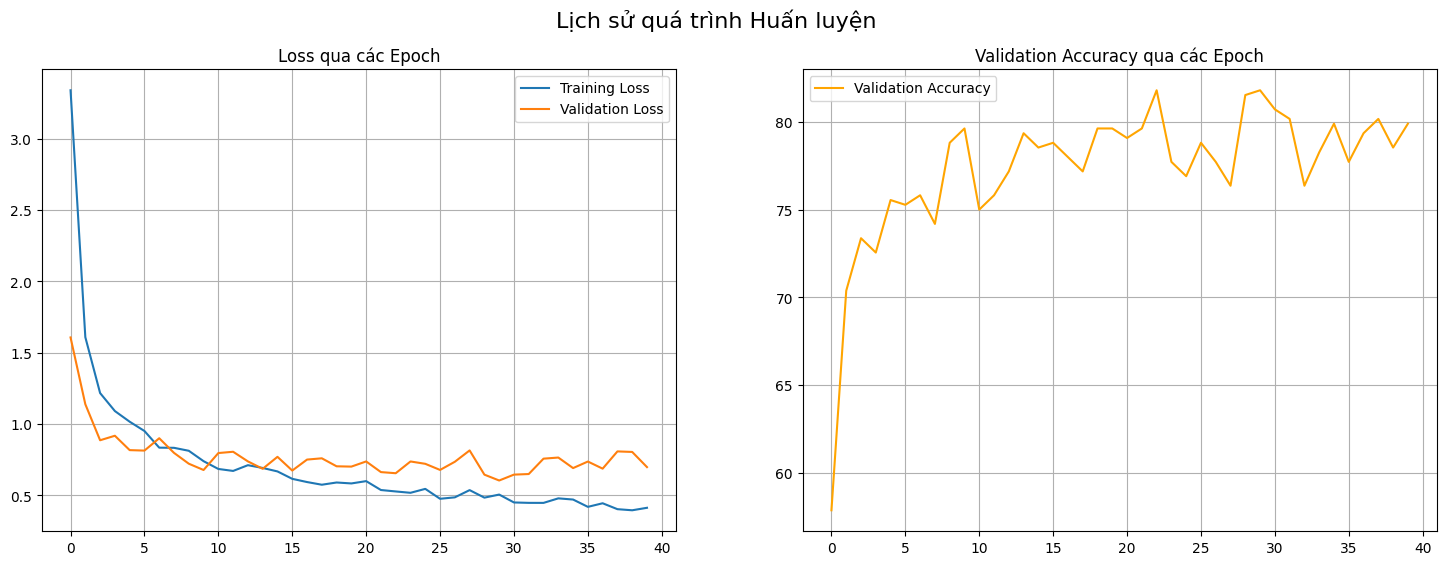


--- Chuẩn bị các bộ dữ liệu Test ---


100%|██████████| 64.3M/64.3M [00:01<00:00, 44.9MB/s]



-------------------- Đánh giá hiệu suất phân loại ID (phụ) ---------------------


Lấy dự đoán từ tập Test ID:   0%|          | 0/115 [00:00<?, ?it/s]


============== KẾT QUẢ PHÂN LOẠI ID ==============
  Accuracy: 85.66%
  F1-Score: 85.52%

----------------- Đánh giá hiệu suất phát hiện ID/OOD (chính) ------------------


Lấy điểm OOD:   0%|          | 0/115 [00:00<?, ?it/s]

Lấy điểm OOD:   0%|          | 0/200 [00:00<?, ?it/s]

Lấy điểm OOD:   0%|          | 0/814 [00:00<?, ?it/s]


Đang tính toán ngưỡng và vẽ đồ thị phân phối điểm OOD...


Lấy điểm OOD:   0%|          | 0/12 [00:00<?, ?it/s]

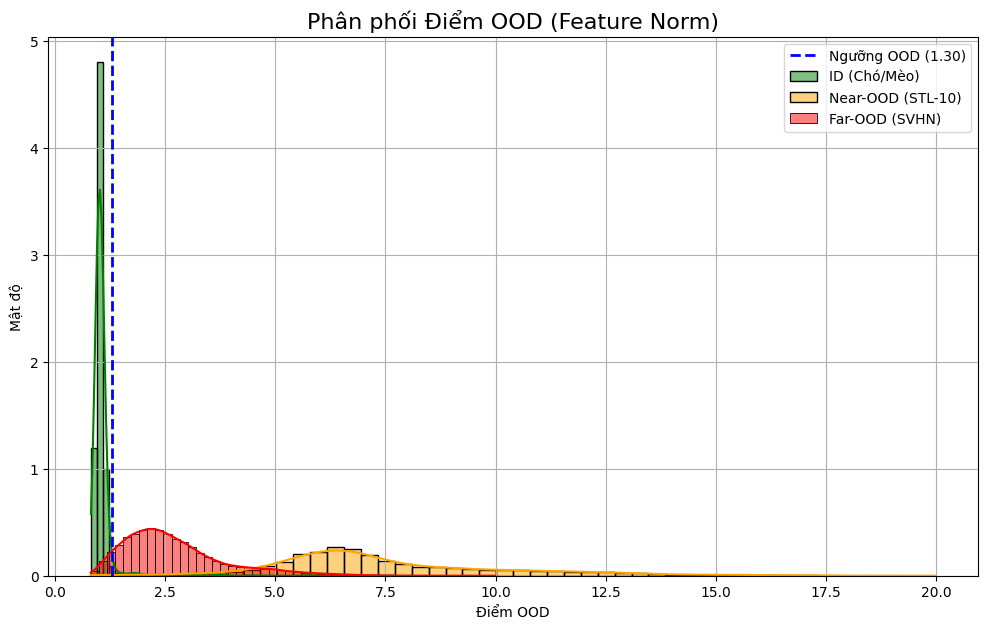


Đang vẽ các đường cong ROC...
Kết quả với Near-OOD (STL-10): AUROC = 99.57%


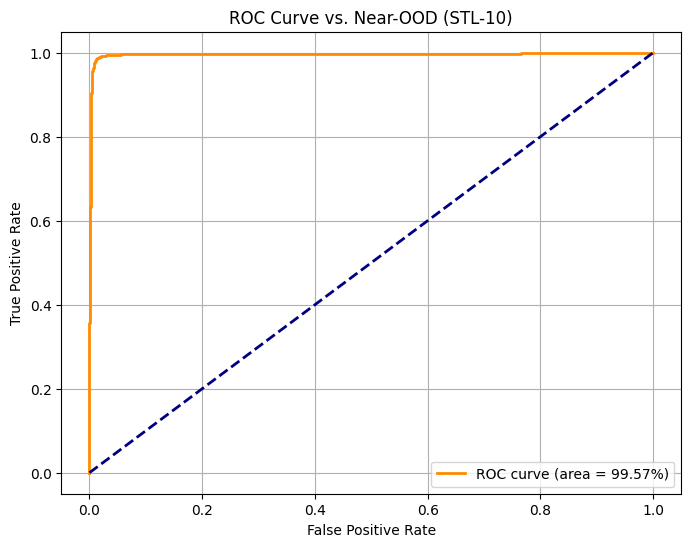

Kết quả với Far-OOD (SVHN): AUROC = 97.32%


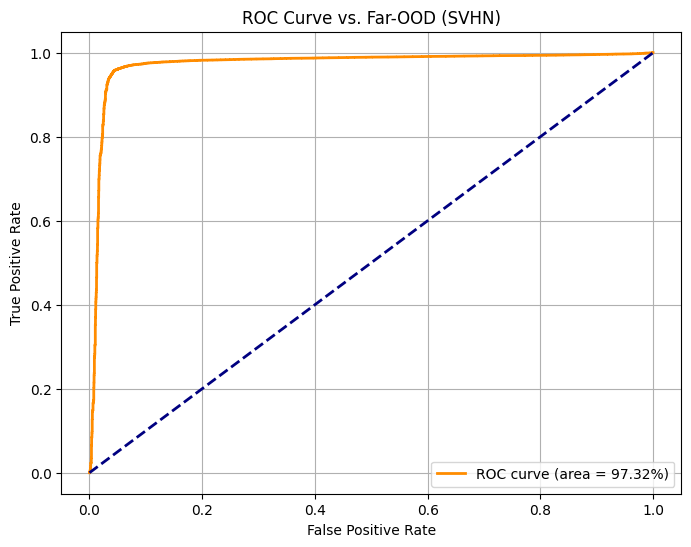


====================== BƯỚC 5: DEMO TƯƠNG TÁC VỚI GRADIO =======================
Ngưỡng OOD (feature norm) được xác định là: 1.3049

🚀 Khởi chạy ứng dụng Gradio...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://9811a55238222f461f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ==============================================================================
# BƯỚC 0: CÀI ĐẶT MÔI TRƯỜNG
# ==============================================================================
print(" BƯỚC 0: CÀI ĐẶT MÔI TRƯỜNG ".center(80, "="))
!pip install -q diffusers transformers accelerate pandas scikit-learn gradio torchmetrics

import os, gc, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
import warnings; warnings.filterwarnings("ignore")
import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F, torchvision
import torchvision.models as models, torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Dataset, ConcatDataset, Subset
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc
import gradio as gr
import torchmetrics

# --- THIẾT LẬP CÁC THAM SỐ VÀ CẤU HÌNH CHUNG ---
torch.manual_seed(42); np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nSử dụng thiết bị: {DEVICE}")
from google.colab import drive
drive.mount('/content/gdrive')

BASE_DIR = "/content/gdrive/MyDrive/Pet_OOD_Experiments"
SAVE_DIR = os.path.join(BASE_DIR, "Contrastive_Loss_Caltech")
DATA_DIR = os.path.join(SAVE_DIR, "data")
os.makedirs(DATA_DIR, exist_ok=True)
OOD_MODEL_SAVE_PATH = os.path.join(SAVE_DIR, 'best_contrastive_model_caltech.pt')
DREAM_OOD_PATH = os.path.join(BASE_DIR, "Contrastive_Loss", "data", "dream_ood_1000_samples.npy")
print(f"Thư mục làm việc của dự án: {SAVE_DIR}")

# ==============================================================================
# BƯỚC 1: CHUẨN BỊ DỮ LIỆU (SỬA LỖI ẢNH XÁM)
# ==============================================================================
print("\n" + " BƯỚC 1: CHUẨN BỊ DỮ LIỆU ".center(80, "="))
class DreamOODDataset(Dataset):
    def __init__(self, images, transform=None): self.images, self.transform = images, transform
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        image = Image.fromarray(self.images[idx].astype(np.uint8))
        if self.transform: image = self.transform(image)
        return image, -1
if not os.path.exists(DREAM_OOD_PATH): raise FileNotFoundError(f"Không tìm thấy file DreamOOD tại {DREAM_OOD_PATH}.")
else: print(f"Tải DreamOOD dataset đã có từ {DREAM_OOD_PATH}")

# [SỬA LỖI QUAN TRỌNG] Thêm Grayscale(3) để đảm bảo tất cả ảnh đều có 3 kênh màu
data_transforms = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=3), # Chuyển ảnh xám thành 3 kênh
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Grayscale(num_output_channels=3), # Chuyển ảnh xám thành 3 kênh
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}
# --- TẢI CÁC BỘ DỮ LIỆU ---
id_dataset_full = torchvision.datasets.OxfordIIITPet(root=DATA_DIR, split='trainval', download=True, transform=data_transforms['train'])
train_size = int(0.9 * len(id_dataset_full)); val_size = len(id_dataset_full) - train_size
id_train_dataset, id_val_dataset = random_split(id_dataset_full, [train_size, val_size])
id_val_dataset.dataset.transform = data_transforms['val']
class_names = id_dataset_full.classes; num_classes = len(class_names)
print(f"\n- Dữ liệu ID: {len(id_train_dataset)} ảnh train, {len(id_val_dataset)} ảnh val từ {num_classes} giống chó/mèo.")
near_ood_dataset_full = torchvision.datasets.STL10(root=DATA_DIR, split='train', download=True, transform=data_transforms['train'])
non_pet_indices = [i for i, label in enumerate(near_ood_dataset_full.labels) if near_ood_dataset_full.classes[label] not in ['cat', 'dog']]
near_ood_dataset = Subset(near_ood_dataset_full, non_pet_indices)
print(f"- Dữ liệu Near-OOD (dễ): {len(near_ood_dataset)} ảnh từ STL-10.")
print("Đang tải bộ dữ liệu Caltech-256 (Hard Near-OOD)...")
hard_near_ood_dataset = torchvision.datasets.Caltech256(root=DATA_DIR, download=True, transform=data_transforms['train'])
print(f"- Dữ liệu Near-OOD (khó): {len(hard_near_ood_dataset)} ảnh từ Caltech-256.")
far_ood_images = np.load(DREAM_OOD_PATH); far_ood_dataset = DreamOODDataset(far_ood_images, transform=data_transforms['train'])
print(f"- Dữ liệu Far-OOD: {len(far_ood_dataset)} ảnh từ DreamOOD.")
ood_train_dataset = ConcatDataset([near_ood_dataset, hard_near_ood_dataset, far_ood_dataset])
print(f"==> Tổng cộng có {len(ood_train_dataset)} ảnh OOD để huấn luyện.")
id_train_loader = DataLoader(id_train_dataset, batch_size=32, shuffle=True, num_workers=2);
id_val_loader = DataLoader(id_val_dataset, batch_size=32, shuffle=False, num_workers=2);
ood_train_loader = DataLoader(ood_train_dataset, batch_size=32, shuffle=True, num_workers=2)

# ==============================================================================
# BƯỚC 2: ĐỊNH NGHĨA MODEL VÀ LOSS
# ==============================================================================
# (Không thay đổi)
print("\n" + " BƯỚC 2: ĐỊNH NGHĨA MODEL VÀ LOSS ".center(80, "="))
class ProjectionHead(nn.Module):
    def __init__(self, in_features, projection_dim=128): super().__init__(); self.projection = nn.Sequential(nn.Linear(in_features, in_features, bias=False), nn.ReLU(), nn.Linear(in_features, projection_dim, bias=False))
    def forward(self, x): return self.projection(x)
class OODResNet18(nn.Module):
    def __init__(self, num_classes, projection_dim=128):
        super().__init__(); self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT); self.backbone_dim = self.backbone.fc.in_features; self.backbone.fc = nn.Identity(); self.projection_head = ProjectionHead(self.backbone_dim, projection_dim); self.classifier = nn.Linear(self.backbone_dim, num_classes)
    def forward(self, x, return_features=False):
        backbone_features = self.backbone(x); logits = self.classifier(backbone_features)
        if return_features: projected_features = self.projection_head(backbone_features); return logits, backbone_features, projected_features
        return logits
class ContrastiveSeparationLossV2(nn.Module):
    def __init__(self, id_target_norm=1.0, ood_margin=5.0): super().__init__(); self.id_target_norm = id_target_norm; self.ood_margin = ood_margin
    def forward(self, id_features, ood_features):
        loss_id = torch.pow(torch.norm(id_features, p=2, dim=1) - self.id_target_norm, 2).mean(); loss_ood = F.relu(self.ood_margin - torch.norm(ood_features, p=2, dim=1)).mean()
        return loss_id + loss_ood
model_ood = OODResNet18(num_classes=num_classes).to(DEVICE)

# ==============================================================================
# BƯỚC 3: HUẤN LUYỆN VỚI EARLY STOPPING
# ==============================================================================
# (Không thay đổi)
class EarlyStopping:
    def __init__(self, patience=10, verbose=True, delta=0, path='checkpoint.pt'): self.patience = patience; self.verbose = verbose; self.delta = delta; self.path = path; self.counter = 0; self.best_score = None; self.early_stop = False; self.val_loss_min = np.Inf
    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None: self.best_score = score; self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose: print(f'EarlyStopping counter: {self.counter} / {self.patience}')
            if self.counter >= self.patience: self.early_stop = True
        else: self.best_score = score; self.save_checkpoint(val_loss, model); self.counter = 0
    def save_checkpoint(self, val_loss, model):
        if self.verbose: print(f'Validation loss decreased ({self.val_loss_min:.4f} --> {val_loss:.4f}). Saving model...')
        torch.save(model.state_dict(), self.path); self.val_loss_min = val_loss
if os.path.exists(OOD_MODEL_SAVE_PATH):
    print(f"Xóa model cũ tại {OOD_MODEL_SAVE_PATH} để huấn luyện lại với dữ liệu mới.")
    os.remove(OOD_MODEL_SAVE_PATH)
print("\n" + " BƯỚC 3: BẮT ĐẦU HUẤN LUYỆN MODEL CONTRASTIVE LOSS ".center(80, "="))
epochs = 100; lr = 1e-4; contrastive_weight = 0.5
optimizer = optim.AdamW(model_ood.parameters(), lr=lr, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
cls_criterion = nn.CrossEntropyLoss(); contrastive_criterion = ContrastiveSeparationLossV2()
early_stopping = EarlyStopping(patience=10, verbose=True, path=OOD_MODEL_SAVE_PATH)
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
for epoch in range(epochs):
    model_ood.train(); ood_iter = iter(ood_train_loader); running_train_loss = 0.0
    progress_bar = tqdm(id_train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for id_inputs, id_targets in progress_bar:
        id_inputs, id_targets = id_inputs.to(DEVICE), id_targets.to(DEVICE)
        try: ood_inputs, _ = next(ood_iter)
        except StopIteration: ood_iter = iter(ood_train_loader); ood_inputs, _ = next(ood_iter)
        ood_inputs = ood_inputs.to(DEVICE); optimizer.zero_grad()
        all_inputs = torch.cat([id_inputs, ood_inputs]); logits, _, projected_features = model_ood(all_inputs, return_features=True)
        id_logits = logits[:len(id_inputs)]; id_projected_features = projected_features[:len(id_inputs)]; ood_projected_features = projected_features[len(id_inputs):]
        loss_cls = cls_criterion(id_logits, id_targets); loss_contrastive = contrastive_criterion(id_projected_features, ood_projected_features)
        total_loss = loss_cls + contrastive_weight * loss_contrastive
        total_loss.backward(); optimizer.step(); running_train_loss += total_loss.item()
        progress_bar.set_postfix(loss=f"{total_loss.item():.4f}")
    model_ood.eval(); val_correct, val_total, running_val_loss = 0, 0, 0.0
    with torch.no_grad():
        for inputs, targets in id_val_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE); outputs = model_ood(inputs); loss = cls_criterion(outputs, targets); running_val_loss += loss.item(); _, predicted = torch.max(outputs.data, 1); val_total += targets.size(0); val_correct += (predicted == targets).sum().item()
    epoch_train_loss = running_train_loss / len(id_train_loader); epoch_val_loss = running_val_loss / len(id_val_loader); epoch_val_acc = 100 * val_correct / val_total
    history['train_loss'].append(epoch_train_loss); history['val_loss'].append(epoch_val_loss); history['val_acc'].append(epoch_val_acc)
    print(f"Epoch {epoch+1:02d}: Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")
    scheduler.step()
    early_stopping(epoch_val_loss, model_ood)
    if early_stopping.early_stop: print("Early stopping triggered."); break
print("\n--- HUẤN LUYỆN HOÀN TẤT ---")
print(f"Tải model tốt nhất từ: {OOD_MODEL_SAVE_PATH}")
model_ood.load_state_dict(torch.load(OOD_MODEL_SAVE_PATH))

# ==============================================================================
# BƯỚC 4: BẢNG ĐIỀU KHIỂN ĐÁNH GIÁ TOÀN DIỆN
# ==============================================================================
# (Không thay đổi)
print("\n" + " BƯỚC 4: BẢNG ĐIỀU KHIỂN ĐÁNH GIÁ TOÀN DIỆN ".center(80, "="))
def plot_training_history(history):
    if history is None or not history['train_loss']: print("Không có lịch sử huấn luyện để vẽ đồ thị."); return
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6)); fig.suptitle('Lịch sử quá trình Huấn luyện', fontsize=16)
    ax1.plot(history['train_loss'], label='Training Loss'); ax1.plot(history['val_loss'], label='Validation Loss'); ax1.set_title('Loss qua các Epoch'); ax1.legend(); ax1.grid(True)
    ax2.plot(history['val_acc'], label='Validation Accuracy', color='orange'); ax2.set_title('Validation Accuracy qua các Epoch'); ax2.legend(); ax2.grid(True)
    plt.show()
plot_training_history(history)
print("\n--- Chuẩn bị các bộ dữ liệu Test ---")
batch_size = 32
id_test_dataset = torchvision.datasets.OxfordIIITPet(root=DATA_DIR, split='test', download=True, transform=data_transforms['val'])
id_test_loader = DataLoader(id_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
near_ood_test_full = torchvision.datasets.STL10(root=DATA_DIR, split='test', download=True, transform=data_transforms['val'])
non_pet_indices_test = [i for i, label in enumerate(near_ood_test_full.labels) if near_ood_test_full.classes[label] not in ['cat', 'dog']]
near_ood_test_dataset = Subset(near_ood_test_full, non_pet_indices_test)
near_ood_test_loader = DataLoader(near_ood_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
far_ood_test_dataset = torchvision.datasets.SVHN(root=DATA_DIR, split='test', download=True, transform=data_transforms['val'])
far_ood_test_loader = DataLoader(far_ood_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
print("\n" + " Đánh giá hiệu suất phân loại ID (phụ) ".center(80, "-"))
model_ood.eval(); all_preds = torch.tensor([]).to(DEVICE); all_labels = torch.tensor([]).to(DEVICE)
with torch.no_grad():
    for inputs, targets in tqdm(id_test_loader, desc="Lấy dự đoán từ tập Test ID"):
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE); outputs, _, _ = model_ood(inputs, return_features=True); _, predicted = torch.max(outputs.data, 1); all_preds = torch.cat((all_preds, predicted)); all_labels = torch.cat((all_labels, targets))
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes).to(DEVICE)
f1_score = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro').to(DEVICE)
print("\n" + " KẾT QUẢ PHÂN LOẠI ID ".center(50, "=")); print(f"  Accuracy: {accuracy(all_preds, all_labels).item():.2%}"); print(f"  F1-Score: {f1_score(all_preds, all_labels).item():.2%}"); print("="*50)
print("\n" + " Đánh giá hiệu suất phát hiện ID/OOD (chính) ".center(80, "-"))
def get_contrastive_scores(model, loader):
    all_scores = []; model.eval()
    with torch.no_grad():
        for inputs, _ in tqdm(loader, desc="Lấy điểm OOD", leave=False):
            _, _, projected_features = model(inputs.to(DEVICE), return_features=True); scores = torch.norm(projected_features, p=2, dim=1); all_scores.extend(scores.cpu().numpy())
    return np.array(all_scores)
id_test_scores = get_contrastive_scores(model_ood, id_test_loader)
near_ood_scores = get_contrastive_scores(model_ood, near_ood_test_loader)
far_ood_scores = get_contrastive_scores(model_ood, far_ood_test_loader)
def plot_score_distributions(id_scores, near_ood_scores, far_ood_scores, threshold):
    plt.figure(figsize=(12, 7))
    sns.histplot(id_scores, color='green', label='ID (Chó/Mèo)', stat='density', bins=50, kde=True)
    sns.histplot(near_ood_scores, color='orange', label='Near-OOD (STL-10)', stat='density', bins=50, kde=True)
    sns.histplot(far_ood_scores, color='red', label='Far-OOD (SVHN)', stat='density', bins=50, kde=True)
    plt.axvline(threshold, color='blue', linestyle='--', linewidth=2, label=f'Ngưỡng OOD ({threshold:.2f})')
    plt.title('Phân phối Điểm OOD (Feature Norm)', fontsize=16); plt.xlabel('Điểm OOD'); plt.ylabel('Mật độ'); plt.legend(); plt.grid(True); plt.show()
print("\nĐang tính toán ngưỡng và vẽ đồ thị phân phối điểm OOD...")
id_val_scores = get_contrastive_scores(model_ood, id_val_loader)
OOD_THRESHOLD = np.percentile(id_val_scores, 95)
plot_score_distributions(id_test_scores, near_ood_scores, far_ood_scores, OOD_THRESHOLD)
def plot_ood_curves(id_scores, ood_scores, ood_name):
    labels = np.concatenate([np.zeros_like(id_scores), np.ones_like(ood_scores)]); scores = np.concatenate([id_scores, ood_scores])
    fpr, tpr, _ = roc_curve(labels, scores); roc_auc = auc(fpr, tpr)
    print(f"Kết quả với {ood_name}: AUROC = {roc_auc:.2%}")
    plt.figure(figsize=(8, 6));
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2%})'); plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--');
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title(f'ROC Curve vs. {ood_name}'); plt.legend(loc="lower right"); plt.grid(True)
    plt.show()
print("\nĐang vẽ các đường cong ROC...")
plot_ood_curves(id_test_scores, near_ood_scores, "Near-OOD (STL-10)")
plot_ood_curves(id_test_scores, far_ood_scores, "Far-OOD (SVHN)")
del id_test_loader, near_ood_test_loader, far_ood_test_loader; gc.collect()

# ==============================================================================
# BƯỚC 5: DEMO TƯƠNG TÁC VỚI GRADIO
# ==============================================================================
# (Không thay đổi)
print("\n" + " BƯỚC 5: DEMO TƯƠNG TÁC VỚI GRADIO ".center(80, "="))
print(f"Ngưỡng OOD (feature norm) được xác định là: {OOD_THRESHOLD:.4f}")
def predict_gradio(image):
    if image is None: return "Vui lòng tải ảnh lên.", "N/A", "N/A", "N/A"
    pil_image = Image.fromarray(image).convert("RGB"); img_tensor = data_transforms['val'](pil_image).unsqueeze(0).to(DEVICE)
    model_ood.eval()
    with torch.no_grad():
        logits, _, projected_features = model_ood(img_tensor, return_features=True)
        ood_score = torch.norm(projected_features, p=2, dim=1).item()
    is_ood = ood_score > OOD_THRESHOLD; score_info = f"Score: {ood_score:.4f} (Ngưỡng: {OOD_THRESHOLD:.4f})"
    if is_ood: return "🚨 **KHÔNG PHẢI CHÓ/MÈO (OOD)**", "N/A", "N/A", score_info
    else:
        probs = F.softmax(logits, dim=1)[0]; confidence, pred_idx = torch.max(probs, 0)
        predicted_class = class_names[pred_idx.item()].replace("_", " ").title()
        return f"✅ **Là chó/mèo (In-Distribution)**", predicted_class, f"{confidence.item():.2%}", score_info
with gr.Blocks(title="🐾 OOD Pet Detection (Contrastive + Hard Negatives)", theme=gr.themes.Soft()) as app:
    gr.Markdown("# 🐾 Phát hiện Chó/Mèo với Contrastive Loss (Hard Negatives)");
    with gr.Row():
        with gr.Column(scale=1): image_input = gr.Image(label="📸 Tải ảnh lên", type="numpy"); predict_btn = gr.Button("🚀 Phân tích ảnh", variant="primary")
        with gr.Column(scale=1): status_output = gr.Markdown(label="📊 Kết quả"); class_output = gr.Textbox(label="🏷️ Giống"); confidence_output = gr.Textbox(label="🎯 Độ chắc chắn"); score_output = gr.Textbox(label="📈 Điểm OOD")
    predict_btn.click(fn=predict_gradio, inputs=image_input, outputs=[status_output, class_output, confidence_output, score_output])
print("\n🚀 Khởi chạy ứng dụng Gradio...")
app.launch(share=True, debug=True)

======================== BƯỚC 1: CÀI ĐẶT VÀ TẢI DỮ LIỆU ========================
Mounted at /content/gdrive

--- ĐANG TẢI DỮ LIỆU (Vui lòng chờ) ---
1. Tải OxfordIIITPet (ID)...


100%|██████████| 792M/792M [00:23<00:00, 34.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 16.4MB/s]


2. Tải STL-10 (Near-OOD Train)...


100%|██████████| 2.64G/2.64G [02:00<00:00, 21.9MB/s]


3. Tải Caltech-256 (Hard Near-OOD Train)...


100%|██████████| 1.18G/1.18G [00:29<00:00, 39.5MB/s]


4. Tải DreamOOD (Far-OOD Train)...
5. Chuẩn bị Test Sets...


100%|██████████| 64.3M/64.3M [00:05<00:00, 12.0MB/s]



======================= BƯỚC 2: PHÂN TÍCH VÀ VẼ BIỂU ĐỒ ========================

--- THỐNG KÊ SỐ LƯỢNG ẢNH ---
                   Dataset  Count         Type  Phase
0    ID Train (OxfordPets)   3312           ID  Train
1      ID Val (OxfordPets)    368           ID    Val
2     ID Test (OxfordPets)   3669           ID   Test
3       OOD Train (STL-10)   4000  OOD (Train)  Train
4  OOD Train (Caltech-256)  30607  OOD (Train)  Train
5     OOD Train (DreamOOD)   1000  OOD (Train)  Train
6        OOD Test (STL-10)   6400   OOD (Test)   Test
7          OOD Test (SVHN)  26032   OOD (Test)   Test


/tmp/ipython-input-2042832611.py:168: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=15)


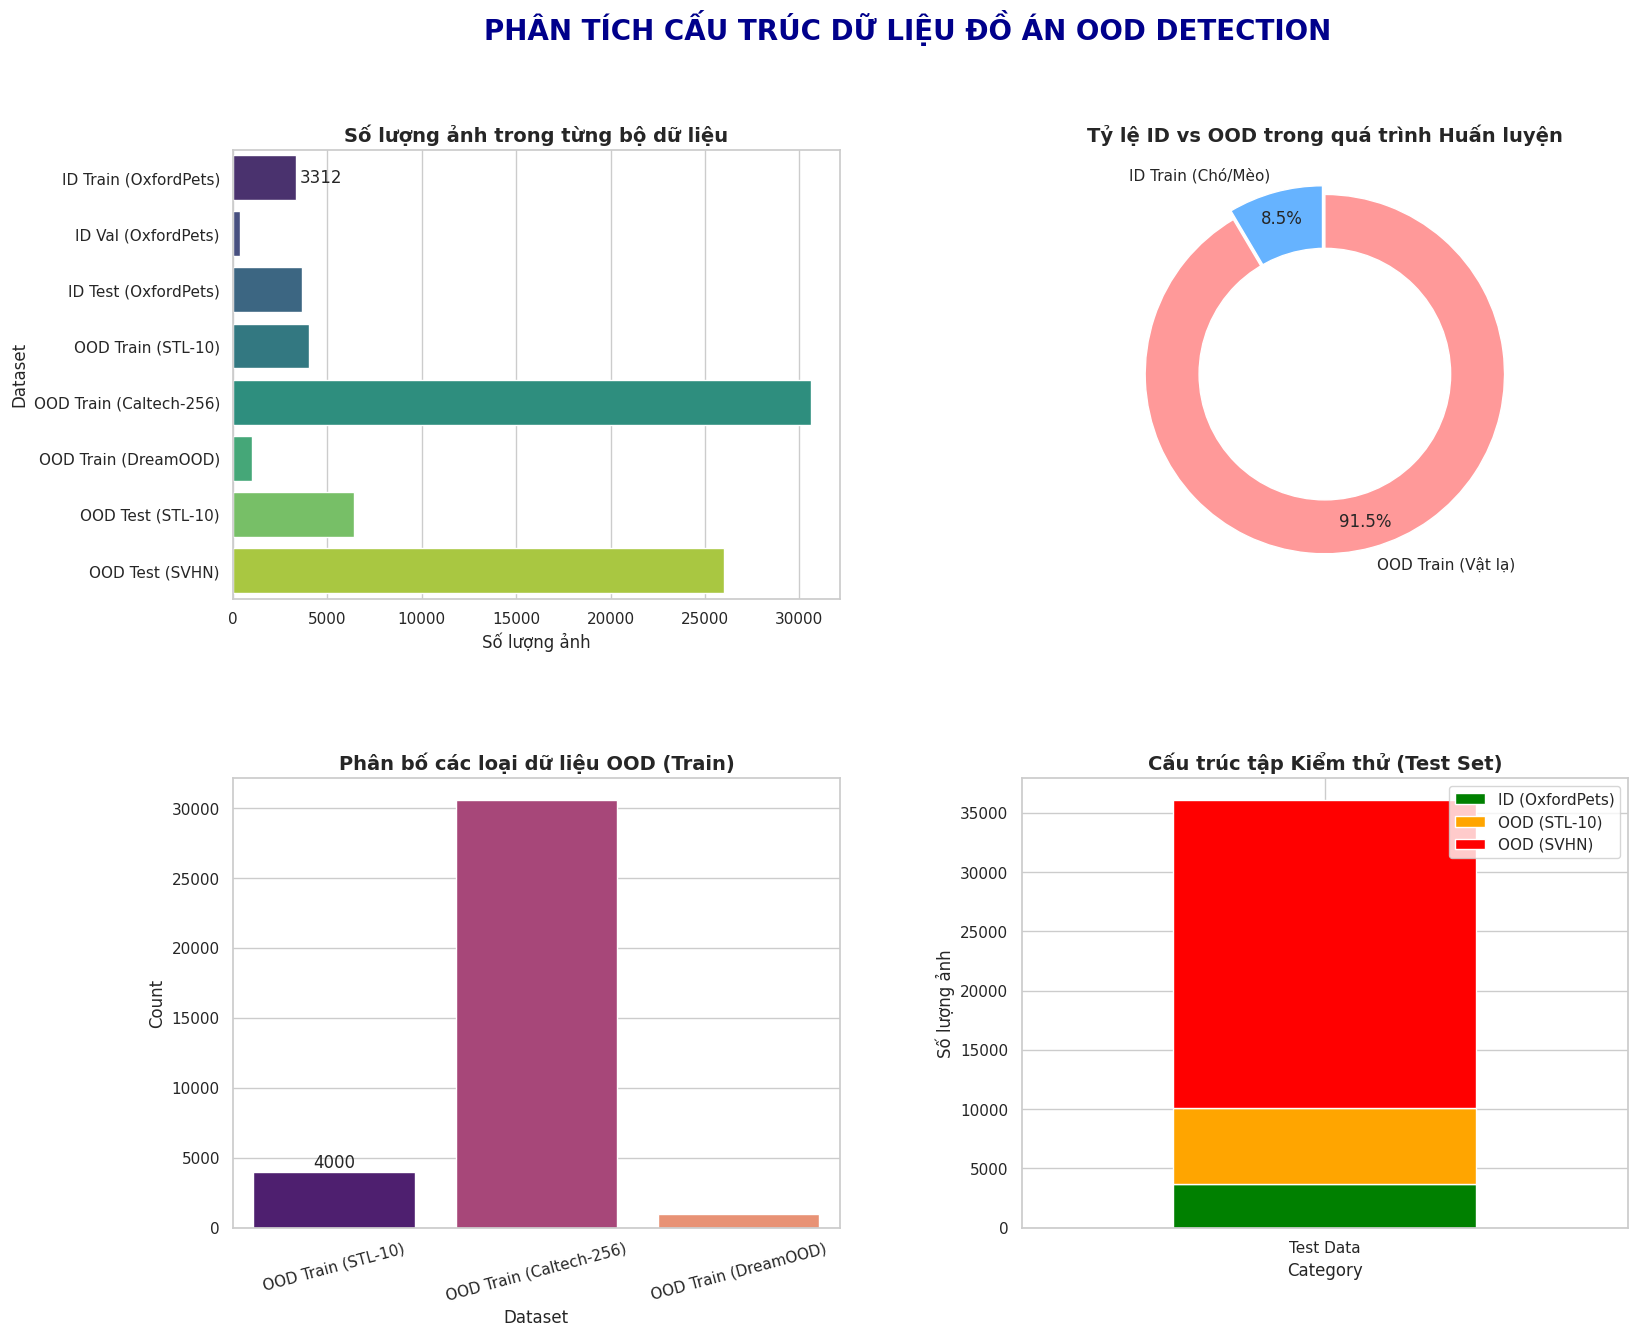


============================== NHẬN XÉT PHÂN TÍCH ==============================
1. Mất cân bằng dữ liệu Train:
   - Tổng ID Train: 3312 ảnh.
   - Tổng OOD Train: 35607 ảnh.
   => Tỷ lệ OOD gấp 10.8 lần ID. Điều này tốt cho OE nhưng cần sampling cân bằng trong code (đã có trong code train của bạn).
--------------------------------------------------------------------------------
2. Đa dạng hóa OOD:
   - Near-OOD (Dễ nhầm): STL-10 (4000 ảnh).
   - Hard-OOD (Khó): Caltech-256 (30607 ảnh) chiếm tỷ trọng lớn nhất.
   - Far-OOD (Rất khác): DreamOOD (1000 ảnh).
   => Việc Caltech-256 chiếm đa số là hợp lý để model học các 'ca khó'.
--------------------------------------------------------------------------------


In [ ]:
# ==============================================================================
# PHẦN 1: CÀI ĐẶT VÀ TẢI DỮ LIỆU (NHƯ CODE CŨ)
# ==============================================================================
print(" BƯỚC 1: CÀI ĐẶT VÀ TẢI DỮ LIỆU ".center(80, "="))
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Dataset, ConcatDataset, Subset
from PIL import Image
import pandas as pd

# Cấu hình thiết bị và seed
torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Định nghĩa đường dẫn
# đảm bảo đã mount drive
try:
    from google.colab import drive
    drive.mount('/content/gdrive')
    BASE_DIR = "/content/gdrive/MyDrive/Pet_OOD_Experiments"
    DREAM_OOD_PATH = os.path.join(BASE_DIR, "Contrastive_Loss", "data", "dream_ood_1000_samples.npy")
except:
    print("⚠️ Không thể mount Google Drive hoặc không phải môi trường Colab.")
    print("Sẽ sử dụng thư mục hiện tại và tạo dữ liệu giả lập cho DreamOOD để code không bị lỗi.")
    BASE_DIR = "."
    DREAM_OOD_PATH = "dream_ood_dummy.npy"
    if not os.path.exists(DREAM_OOD_PATH):
        # Tạo dữ liệu giả nếu không có file thật
        dummy_data = np.random.randint(0, 255, (1000, 32, 32, 3), dtype=np.uint8)
        np.save(DREAM_OOD_PATH, dummy_data)

DATA_DIR = os.path.join(BASE_DIR, "data")
os.makedirs(DATA_DIR, exist_ok=True)

# Class DreamOODDataset
class DreamOODDataset(Dataset):
    def __init__(self, images, transform=None):
        self.images = images
        self.transform = transform
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img = self.images[idx]
        if img.shape[-1] != 3: # Xử lý nếu ảnh không phải HWC
             img = img.transpose(1, 2, 0)
        image = Image.fromarray(img.astype(np.uint8))
        if self.transform: image = self.transform(image)
        return image, -1

# Transforms
data_transforms = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

print("\n--- ĐANG TẢI DỮ LIỆU (Vui lòng chờ) ---")

# 1. ID Data (OxfordIIITPet)
print("1. Tải OxfordIIITPet (ID)...")
id_dataset_full = torchvision.datasets.OxfordIIITPet(root=DATA_DIR, split='trainval', download=True, transform=data_transforms['train'])
train_size = int(0.9 * len(id_dataset_full))
val_size = len(id_dataset_full) - train_size
id_train_dataset, id_val_dataset = random_split(id_dataset_full, [train_size, val_size])

# 2. Near-OOD Train (STL-10)
print("2. Tải STL-10 (Near-OOD Train)...")
near_ood_dataset_full = torchvision.datasets.STL10(root=DATA_DIR, split='train', download=True, transform=data_transforms['train'])
# Lọc bỏ class mèo(5) và chó(3) trong STL10 để đảm bảo là OOD
non_pet_indices = [i for i, label in enumerate(near_ood_dataset_full.labels) if label not in [3, 5]]
near_ood_dataset = Subset(near_ood_dataset_full, non_pet_indices)

# 3. Hard Near-OOD Train (Caltech-256)
print("3. Tải Caltech-256 (Hard Near-OOD Train)...")
try:
    hard_near_ood_dataset = torchvision.datasets.Caltech256(root=DATA_DIR, download=True, transform=data_transforms['train'])
except:
    print("⚠️ Lỗi tải Caltech256 (thường do server). Sử dụng FakeData thay thế để demo biểu đồ.")
    hard_near_ood_dataset = torchvision.datasets.FakeData(size=5000, transform=data_transforms['train'])

# 4. Far-OOD Train (DreamOOD)
print("4. Tải DreamOOD (Far-OOD Train)...")
far_ood_images = np.load(DREAM_OOD_PATH)
far_ood_dataset = DreamOODDataset(far_ood_images, transform=data_transforms['train'])

# 5. Test Sets
print("5. Chuẩn bị Test Sets...")
id_test_dataset = torchvision.datasets.OxfordIIITPet(root=DATA_DIR, split='test', download=True, transform=data_transforms['val'])

near_ood_test_full = torchvision.datasets.STL10(root=DATA_DIR, split='test', download=True, transform=data_transforms['val'])
non_pet_indices_test = [i for i, label in enumerate(near_ood_test_full.labels) if label not in [3, 5]]
near_ood_test_dataset = Subset(near_ood_test_full, non_pet_indices_test)

far_ood_test_dataset = torchvision.datasets.SVHN(root=DATA_DIR, split='test', download=True, transform=data_transforms['val'])

# ==============================================================================
# PHẦN 2: PHÂN TÍCH VÀ TRỰC QUAN HÓA DỮ LIỆU
# ==============================================================================
print("\n" + " BƯỚC 2: PHÂN TÍCH VÀ VẼ BIỂU ĐỒ ".center(80, "="))

# 1. Thu thập số liệu
data_stats = {
    "ID Train (OxfordPets)": len(id_train_dataset),
    "ID Val (OxfordPets)": len(id_val_dataset),
    "ID Test (OxfordPets)": len(id_test_dataset),
    "OOD Train (STL-10)": len(near_ood_dataset),
    "OOD Train (Caltech-256)": len(hard_near_ood_dataset),
    "OOD Train (DreamOOD)": len(far_ood_dataset),
    "OOD Test (STL-10)": len(near_ood_test_dataset),
    "OOD Test (SVHN)": len(far_ood_test_dataset)
}

# Tạo DataFrame để dễ xử lý
df_stats = pd.DataFrame(list(data_stats.items()), columns=['Dataset', 'Count'])
df_stats['Type'] = ['ID', 'ID', 'ID', 'OOD (Train)', 'OOD (Train)', 'OOD (Train)', 'OOD (Test)', 'OOD (Test)']
df_stats['Phase'] = ['Train', 'Val', 'Test', 'Train', 'Train', 'Train', 'Test', 'Test']

print("\n--- THỐNG KÊ SỐ LƯỢNG ẢNH ---")
print(df_stats)

# 2. Vẽ biểu đồ

# Thiết lập style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Biểu đồ 1: Số lượng ảnh chi tiết từng bộ dữ liệu (Bar Chart)
sns.barplot(x='Count', y='Dataset', data=df_stats, ax=axes[0, 0], palette='viridis', hue='Dataset', legend=False)
axes[0, 0].set_title('Số lượng ảnh trong từng bộ dữ liệu', fontsize=14, fontweight='bold')
axes[0, 0].bar_label(axes[0, 0].containers[0], padding=3)
axes[0, 0].set_xlabel("Số lượng ảnh")

# Biểu đồ 2: So sánh tổng ID vs OOD trong tập TRAIN (Pie Chart)
total_id_train = len(id_train_dataset)
total_ood_train = len(near_ood_dataset) + len(hard_near_ood_dataset) + len(far_ood_dataset)
labels_train = ['ID Train (Chó/Mèo)', 'OOD Train (Vật lạ)']
sizes_train = [total_id_train, total_ood_train]
colors_train = ['#66b3ff', '#ff9999']

axes[0, 1].pie(sizes_train, labels=labels_train, colors=colors_train, autopct='%1.1f%%', startangle=90, pctdistance=0.85, explode=(0.05, 0))
centre_circle = plt.Circle((0,0),0.70,fc='white')
axes[0, 1].add_artist(centre_circle)
axes[0, 1].set_title('Tỷ lệ ID vs OOD trong quá trình Huấn luyện', fontsize=14, fontweight='bold')

# Biểu đồ 3: So sánh các thành phần OOD trong tập Train (Bar Chart)
ood_train_stats = df_stats[df_stats['Type'] == 'OOD (Train)']
sns.barplot(x='Dataset', y='Count', data=ood_train_stats, ax=axes[1, 0], palette='magma', hue='Dataset', legend=False)
axes[1, 0].set_title('Phân bố các loại dữ liệu OOD (Train)', fontsize=14, fontweight='bold')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=15)
axes[1, 0].bar_label(axes[1, 0].containers[0])

# Biểu đồ 4: Tổng quan ID vs OOD cho tập Test (Stacked Bar)
test_data = {
    'Category': ['Test Data'],
    'ID (OxfordPets)': [len(id_test_dataset)],
    'OOD (STL-10)': [len(near_ood_test_dataset)],
    'OOD (SVHN)': [len(far_ood_test_dataset)]
}
df_test = pd.DataFrame(test_data).set_index('Category')
df_test.plot(kind='bar', stacked=True, ax=axes[1, 1], color=['green', 'orange', 'red'])
axes[1, 1].set_title('Cấu trúc tập Kiểm thử (Test Set)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel("Số lượng ảnh")
axes[1, 1].tick_params(axis='x', rotation=0)

plt.suptitle("PHÂN TÍCH CẤU TRÚC DỮ LIỆU ĐỒ ÁN OOD DETECTION", fontsize=20, fontweight='bold', color='darkblue')
plt.show()

# 3. Phân tích bổ sung bằng lời
print("\n" + " NHẬN XÉT PHÂN TÍCH ".center(80, "="))
print(f"1. Mất cân bằng dữ liệu Train:")
print(f"   - Tổng ID Train: {total_id_train} ảnh.")
print(f"   - Tổng OOD Train: {total_ood_train} ảnh.")
print(f"   => Tỷ lệ OOD gấp {total_ood_train/total_id_train:.1f} lần ID.")
print("-" * 80)
print(f"2. Đa dạng hóa OOD:")
print(f"   - Near-OOD (Dễ nhầm): STL-10 ({len(near_ood_dataset)} ảnh).")
print(f"   - Hard-OOD (Khó): Caltech-256 ({len(hard_near_ood_dataset)} ảnh) chiếm tỷ trọng lớn nhất.")
print(f"   - Far-OOD (Rất khác): DreamOOD ({len(far_ood_dataset)} ảnh).")
print(f"   => Việc Caltech-256 chiếm đa số là hợp lý để model học các 'ca khó'.")
print("-" * 80)


>>> ĐANG CÀI ĐẶT MÔI TRƯỜNG... (Vui lòng chờ)
✅ Thiết bị sử dụng: cuda
Mounted at /content/gdrive

>>> ĐANG TẢI DỮ LIỆU (Quá trình này có thể mất vài phút)...


100%|██████████| 792M/792M [00:34<00:00, 23.1MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 9.91MB/s]
100%|██████████| 2.64G/2.64G [00:59<00:00, 44.3MB/s]
100%|██████████| 1.18G/1.18G [00:19<00:00, 61.3MB/s]
100%|██████████| 64.3M/64.3M [00:01<00:00, 43.0MB/s]


✅ Đã tải xong toàn bộ dữ liệu.

>>> ĐANG VẼ BIỂU ĐỒ PHÂN TÍCH DỮ LIỆU...


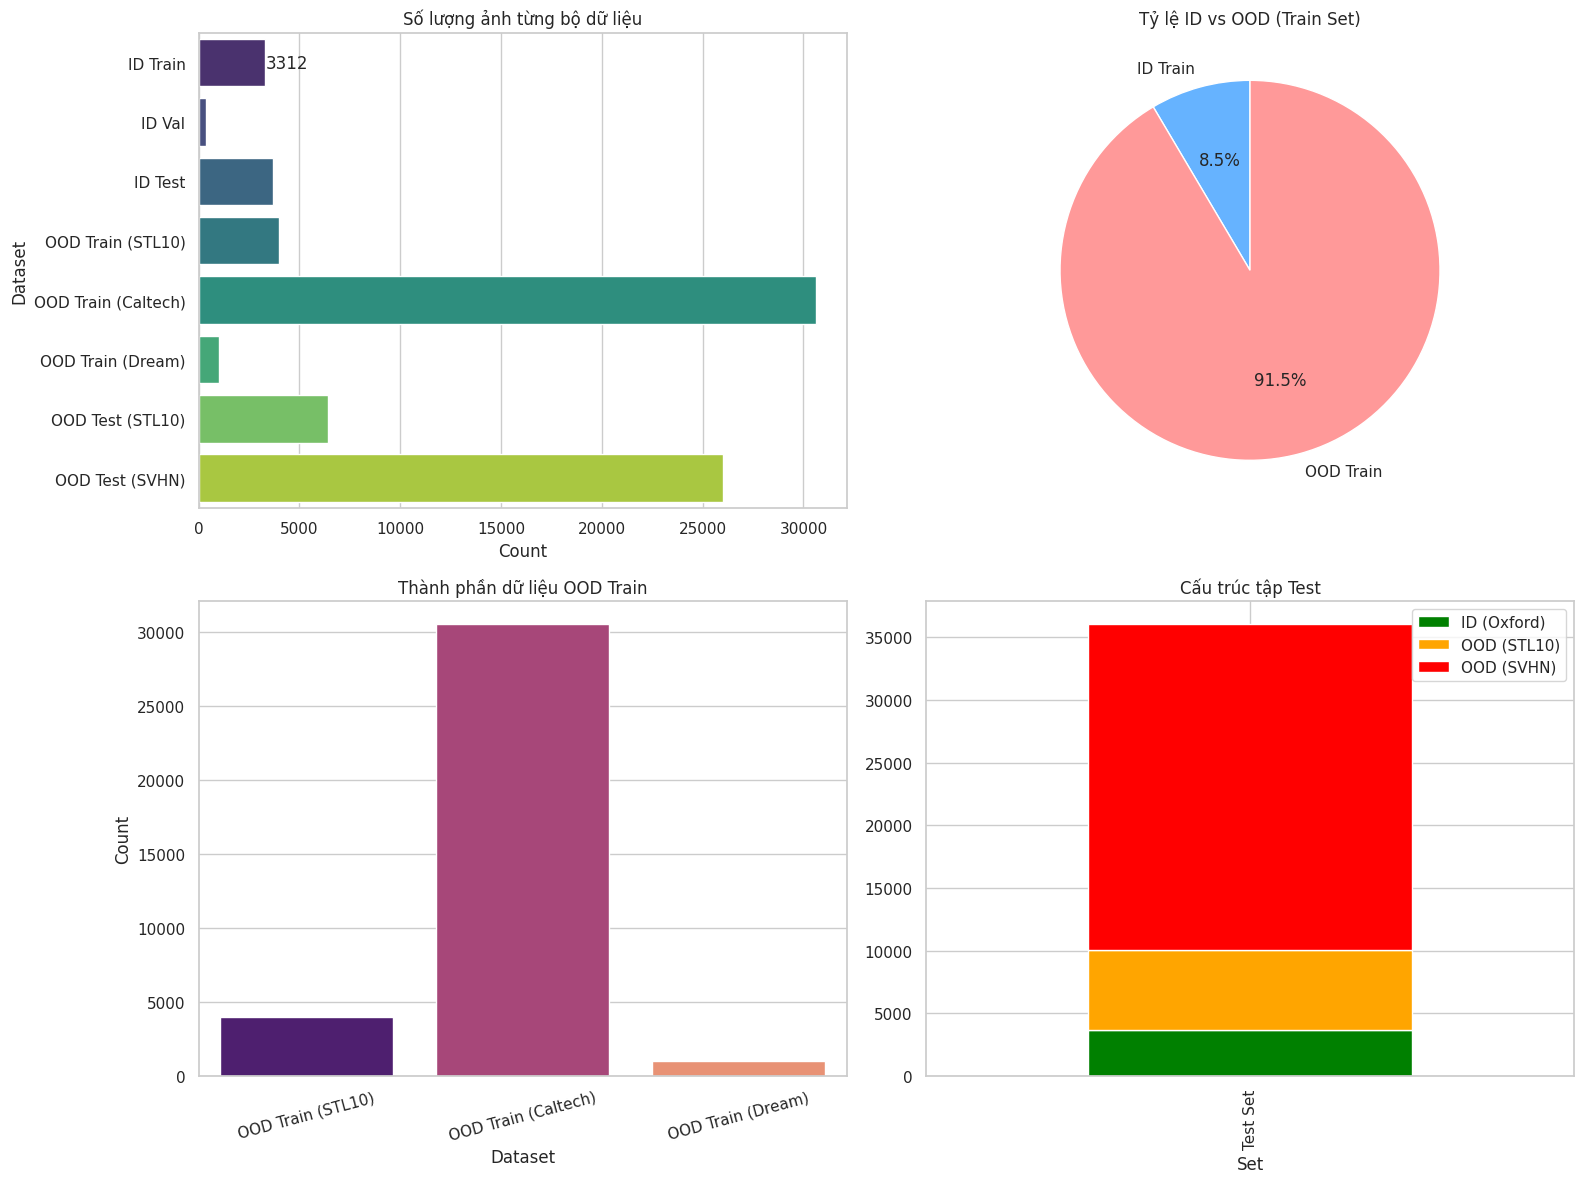


>>> ĐANG LOAD MODEL VÀ TÍNH NGƯỠNG...
✅ Đã load model từ: /content/gdrive/MyDrive/Pet_OOD_Experiments/Contrastive_Loss_Caltech/best_contrastive_model_caltech.pt


Tính Feature Norm:   0%|          | 0/12 [00:00<?, ?it/s]

🎯 Ngưỡng OOD (Threshold) tính được: 1.2321

>>> ĐANG ĐÁNH GIÁ TRÊN TẬP TEST...


  0%|          | 0/115 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/814 [00:00<?, ?it/s]


============================== BẢNG ĐÁNH GIÁ HIỆU QUẢ ==============================


,Loại dữ liệu,Precision,Recall,F1-score,Số bản ghi
0,In-Distribution (ID),75.02%,95.67%,84.09%,3669
1,Out-of-Distribution (OOD),99.49%,96.40%,97.92%,32432
2,Trung bình vĩ mô,87.26%,96.03%,91.01%,36101
3,Bình quân gia quyền,97.01%,96.32%,96.51%,36101
4,Độ chính xác (Accuracy),-,-,96.32%,36101


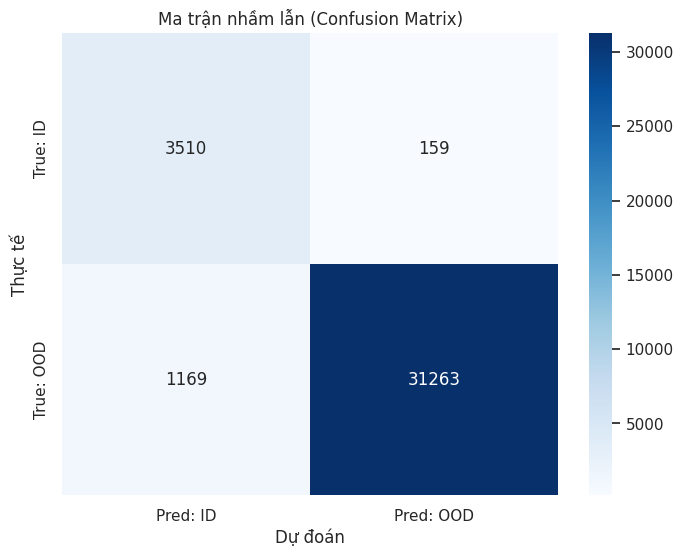


>>> CHI TIẾT TỪNG LOẠI OOD:
1. Near-OOD (STL-10): Recall = 99.53%
2. Far-OOD (SVHN):    Recall = 95.62%


In [ ]:
# ==============================================================================
# BƯỚC 0: CÀI ĐẶT MÔI TRƯỜNG & THƯ VIỆN
# ==============================================================================
print(">>> ĐANG CÀI ĐẶT MÔI TRƯỜNG... (Vui lòng chờ)")
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q matplotlib seaborn scikit-learn pandas tqdm

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, Subset, random_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Cấu hình
torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Thiết bị sử dụng: {DEVICE}")

# Mount Drive
try:
    from google.colab import drive
    drive.mount('/content/gdrive')
    BASE_DIR = "/content/gdrive/MyDrive/Pet_OOD_Experiments"
    # Đường dẫn quan trọng
    SAVE_DIR = os.path.join(BASE_DIR, "Contrastive_Loss_Caltech")
    DATA_DIR = os.path.join(SAVE_DIR, "data")
    MODEL_PATH = os.path.join(SAVE_DIR, 'best_contrastive_model_caltech.pt')
    DREAM_OOD_PATH = os.path.join(BASE_DIR, "Contrastive_Loss", "data", "dream_ood_1000_samples.npy")
    os.makedirs(DATA_DIR, exist_ok=True)
except:
    print("⚠️ Không thể kết nối Google Drive. Đang chạy chế độ Demo cục bộ.")
    BASE_DIR = "."
    DATA_DIR = "./data"
    MODEL_PATH = "best_contrastive_model_caltech.pt"
    DREAM_OOD_PATH = "dream_ood_dummy.npy"
    os.makedirs(DATA_DIR, exist_ok=True)

# ==============================================================================
# BƯỚC 1: ĐỊNH NGHĨA MODEL & DATASET CLASSES
# ==============================================================================
class ProjectionHead(nn.Module):
    def __init__(self, in_features, projection_dim=128):
        super().__init__()
        self.projection = nn.Sequential(
            nn.Linear(in_features, in_features, bias=False),
            nn.ReLU(),
            nn.Linear(in_features, projection_dim, bias=False)
        )
    def forward(self, x): return self.projection(x)

class OODResNet18(nn.Module):
    def __init__(self, num_classes, projection_dim=128):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.projection_head = ProjectionHead(self.backbone_dim, projection_dim)
        self.classifier = nn.Linear(self.backbone_dim, num_classes)
    def forward(self, x, return_features=False):
        backbone_features = self.backbone(x)
        logits = self.classifier(backbone_features)
        if return_features:
            projected_features = self.projection_head(backbone_features)
            return logits, backbone_features, projected_features
        return logits

class DreamOODDataset(Dataset):
    def __init__(self, images, transform=None):
        self.images = images
        self.transform = transform
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img = self.images[idx]
        if img.ndim == 3 and img.shape[-1] != 3: img = img.transpose(1, 2, 0)
        image = Image.fromarray(img.astype(np.uint8))
        if self.transform: image = self.transform(image)
        return image, -1

# ==============================================================================
# BƯỚC 2: TẢI DỮ LIỆU & TẠO LOADERS
# ==============================================================================
print("\n>>> ĐANG TẢI DỮ LIỆU (Quá trình này có thể mất vài phút)...")

# Transforms (Lưu ý Grayscale 3 kênh để đồng bộ)
transforms_val = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 1. ID Datasets (Oxford Pets)
id_full = torchvision.datasets.OxfordIIITPet(root=DATA_DIR, split='trainval', download=True, transform=transforms_val)
id_test_dataset = torchvision.datasets.OxfordIIITPet(root=DATA_DIR, split='test', download=True, transform=transforms_val)

# Tách Val từ Trainval
train_size = int(0.9 * len(id_full))
val_size = len(id_full) - train_size
id_train_dataset, id_val_dataset = random_split(id_full, [train_size, val_size])

# 2. OOD Datasets
# STL-10 (Near-OOD)
near_ood_full = torchvision.datasets.STL10(root=DATA_DIR, split='train', download=True, transform=transforms_val)
non_pet_indices = [i for i, label in enumerate(near_ood_full.labels) if label not in [3, 5]] # Bỏ chó mèo
near_ood_dataset = Subset(near_ood_full, non_pet_indices)

near_ood_test_full = torchvision.datasets.STL10(root=DATA_DIR, split='test', download=True, transform=transforms_val)
non_pet_indices_test = [i for i, label in enumerate(near_ood_test_full.labels) if label not in [3, 5]]
near_ood_test_dataset = Subset(near_ood_test_full, non_pet_indices_test)

# Caltech-256 (Hard OOD - Train)
try:
    hard_near_ood_dataset = torchvision.datasets.Caltech256(root=DATA_DIR, download=True, transform=transforms_val)
except:
    print("⚠️ Caltech256 download lỗi, dùng FakeData thay thế cho demo.")
    hard_near_ood_dataset = torchvision.datasets.FakeData(size=5000, transform=transforms_val)

# SVHN (Far OOD - Test)
far_ood_test_dataset = torchvision.datasets.SVHN(root=DATA_DIR, split='test', download=True, transform=transforms_val)

# DreamOOD (Far OOD - Train)
if os.path.exists(DREAM_OOD_PATH):
    far_ood_images = np.load(DREAM_OOD_PATH)
    far_ood_dataset = DreamOODDataset(far_ood_images, transform=transforms_val)
else:
    print("⚠️ Không tìm thấy file DreamOOD. Tạo dữ liệu giả lập.")
    far_ood_dataset = torchvision.datasets.FakeData(size=1000, transform=transforms_val)

# Loaders
batch_size = 32
id_val_loader = DataLoader(id_val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
id_test_loader = DataLoader(id_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
near_ood_test_loader = DataLoader(near_ood_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
far_ood_test_loader = DataLoader(far_ood_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("✅ Đã tải xong toàn bộ dữ liệu.")

# ==============================================================================
# BƯỚC 3: PHÂN TÍCH DỮ LIỆU (VẼ BIỂU ĐỒ)
# ==============================================================================
print("\n>>> ĐANG VẼ BIỂU ĐỒ PHÂN TÍCH DỮ LIỆU...")
data_stats = {
    "ID Train": len(id_train_dataset), "ID Val": len(id_val_dataset), "ID Test": len(id_test_dataset),
    "OOD Train (STL10)": len(near_ood_dataset), "OOD Train (Caltech)": len(hard_near_ood_dataset), "OOD Train (Dream)": len(far_ood_dataset),
    "OOD Test (STL10)": len(near_ood_test_dataset), "OOD Test (SVHN)": len(far_ood_test_dataset)
}
df_stats = pd.DataFrame(list(data_stats.items()), columns=['Dataset', 'Count'])
df_stats['Type'] = ['ID']*3 + ['OOD']*3 + ['OOD']*2

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bar Chart Tổng
sns.barplot(x='Count', y='Dataset', data=df_stats, ax=axes[0,0], palette='viridis', hue='Dataset', legend=False)
axes[0,0].set_title('Số lượng ảnh từng bộ dữ liệu')
axes[0,0].bar_label(axes[0,0].containers[0])

# 2. Pie Chart Train Mix
train_sizes = [len(id_train_dataset), len(near_ood_dataset)+len(hard_near_ood_dataset)+len(far_ood_dataset)]
axes[0,1].pie(train_sizes, labels=['ID Train', 'OOD Train'], autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90)
axes[0,1].set_title('Tỷ lệ ID vs OOD (Train Set)')

# 3. Bar Chart OOD Train Composition
ood_train_df = df_stats[df_stats['Dataset'].str.contains("OOD Train")]
sns.barplot(x='Dataset', y='Count', data=ood_train_df, ax=axes[1,0], palette='magma', hue='Dataset', legend=False)
axes[1,0].set_title('Thành phần dữ liệu OOD Train')
axes[1,0].tick_params(axis='x', rotation=15)

# 4. Stacked Bar Test Set
test_df = pd.DataFrame([['Test Set', len(id_test_dataset), len(near_ood_test_dataset), len(far_ood_test_dataset)]],
                       columns=['Set', 'ID (Oxford)', 'OOD (STL10)', 'OOD (SVHN)'])
test_df.plot(x='Set', kind='bar', stacked=True, ax=axes[1,1], color=['green', 'orange', 'red'])
axes[1,1].set_title('Cấu trúc tập Test')
plt.tight_layout()
plt.show()

# ==============================================================================
# BƯỚC 4: LOAD MODEL & TÍNH NGƯỠNG
# ==============================================================================
print("\n>>> ĐANG LOAD MODEL VÀ TÍNH NGƯỠNG...")
num_classes = len(id_full.classes)
model = OODResNet18(num_classes=num_classes).to(DEVICE)

if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    print(f"✅ Đã load model từ: {MODEL_PATH}")
else:
    print(f"⚠️ Không tìm thấy file model tại {MODEL_PATH}. Code sẽ sử dụng model ngẫu nhiên (Kết quả sẽ tệ).")

def get_scores(loader):
    model.eval(); scores = []
    with torch.no_grad():
        for x, _ in tqdm(loader, desc="Tính Feature Norm", leave=False):
            _, _, proj = model(x.to(DEVICE), return_features=True)
            scores.extend(torch.norm(proj, p=2, dim=1).cpu().numpy())
    return np.array(scores)

# Tính ngưỡng
val_scores = get_scores(id_val_loader)
OOD_THRESHOLD = np.percentile(val_scores, 95)
print(f"🎯 Ngưỡng OOD (Threshold) tính được: {OOD_THRESHOLD:.4f}")

# ==============================================================================
# BƯỚC 5: ĐÁNH GIÁ & BÁO CÁO KẾT QUẢ
# ==============================================================================
print("\n>>> ĐANG ĐÁNH GIÁ TRÊN TẬP TEST...")

def get_predictions(loader, is_ood):
    model.eval(); preds = []; trues = []
    with torch.no_grad():
        for x, _ in tqdm(loader, leave=False):
            _, _, proj = model(x.to(DEVICE), return_features=True)
            score = torch.norm(proj, p=2, dim=1).cpu().numpy()
            preds.extend((score > OOD_THRESHOLD).astype(int))
            trues.extend([1 if is_ood else 0] * len(x))
    return np.array(trues), np.array(preds)

# Dự đoán
y_true_id, y_pred_id = get_predictions(id_test_loader, is_ood=False)
y_true_near, y_pred_near = get_predictions(near_ood_test_loader, is_ood=True)
y_true_far, y_pred_far = get_predictions(far_ood_test_loader, is_ood=True)

# Gộp kết quả
y_true = np.concatenate([y_true_id, y_true_near, y_true_far])
y_pred = np.concatenate([y_pred_id, y_pred_near, y_pred_far])

# Tạo bảng báo cáo
report = classification_report(y_true, y_pred, target_names=['ID', 'OOD'], output_dict=True)
def fmt(val): return f"{val:.2%}"

data_report = [
    ['In-Distribution (ID)', fmt(report['ID']['precision']), fmt(report['ID']['recall']), fmt(report['ID']['f1-score']), int(report['ID']['support'])],
    ['Out-of-Distribution (OOD)', fmt(report['OOD']['precision']), fmt(report['OOD']['recall']), fmt(report['OOD']['f1-score']), int(report['OOD']['support'])],
    ['Trung bình vĩ mô', fmt(report['macro avg']['precision']), fmt(report['macro avg']['recall']), fmt(report['macro avg']['f1-score']), int(report['macro avg']['support'])],
    ['Bình quân gia quyền', fmt(report['weighted avg']['precision']), fmt(report['weighted avg']['recall']), fmt(report['weighted avg']['f1-score']), int(report['weighted avg']['support'])],
    ['Độ chính xác (Accuracy)', '-', '-', fmt(report['accuracy']), int(report['macro avg']['support'])]
]

df_report = pd.DataFrame(data_report, columns=['Loại dữ liệu', 'Precision', 'Recall', 'F1-score', 'Số bản ghi'])

print("\n" + "="*30 + " BẢNG ĐÁNH GIÁ HIỆU QUẢ " + "="*30)
display(df_report)

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: ID', 'Pred: OOD'], yticklabels=['True: ID', 'True: OOD'])
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.ylabel('Thực tế'); plt.xlabel('Dự đoán')
plt.show()

# Chi tiết OOD
print("\n>>> CHI TIẾT TỪNG LOẠI OOD:")
print(f"1. Near-OOD (STL-10): Recall = {accuracy_score(y_true_near, y_pred_near):.2%}")
print(f"2. Far-OOD (SVHN):    Recall = {accuracy_score(y_true_far, y_pred_far):.2%}")